# EDIS 8100 · Week 7 · Self-Regulated Learning Traces Lab

**Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Estimated time: about 30 minutes for the core path. Guest this week: Conrad Borchers, Carnegie Mellon University.

Today we open the log file of an adaptive practice tutor and ask a hard question: can a stream of timestamped clicks tell us anything real about how a student regulates their own learning?

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Build an **action frequency profile** for each student from raw tutor traces, and explain why two students with the same number of actions can be doing completely different things.
2. Write and apply a **pattern matcher** that decides whether a tutor session contains a particular ordered sequence of logged actions, using a definition you can state out loud and defend, and say what that sequence is and is not evidence of.
3. Use **inter-action timing**, not action counts, to distinguish help seeking spread over minutes from runs of hint requests seconds apart, and say what a log cannot tell you about either.
4. Read an **n-gram transition heatmap** of action types and say what it does and does not show about self-regulated learning.

## How this notebook works (read this if you are new to code)

- Run the cells from top to bottom. Click a cell and press **Shift+Enter**, or use the play button on the left.
- **Nothing here can break your computer.** This notebook writes a few CSV files into its own temporary folder and nothing else. It never touches the internet and never touches real student records.
- If something looks wrong, the fix is almost always to start over from the top: **Runtime > Restart and run all** in Colab, or **Kernel > Restart & Run All** in Jupyter.
- The core path runs untouched. The cells marked **✏️ Your turn** already contain working values, so you can run right past them the first time and come back after class.
- You are not expected to write code from scratch today. You are expected to read numbers and pictures and argue about what they mean. That is the doctoral skill.

## ⚙️ Setup: run the next cell first

The cell below builds this week's synthetic datasets (`students.csv`, `srl_traces.csv`, and `gradebook.csv`) directly inside your Colab or Jupyter runtime, so there is nothing to download and nothing to log into.

The data are synthetic **on purpose**. Learning analytics runs on records about people who rarely got to weigh in on being measured, and a course assignment is a poor reason to touch anyone's real tutor logs. We built a world instead so we can rehearse the judgment without surveilling a single person. The ask in return: treat this data as if it were real.

In [1]:
# ⚙️ SETUP CELL. This is long, and that is fine.
# It lives here so the notebook works anywhere with no downloads and no accounts.
# You do not need to read it. Collapse it (click the little arrow to the left of
# the cell) and move on. Just run it once.

"""EDIS 8100 data generation, the subset needed for week07.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GRADEBOOK = SEED + 2
SEED_SRL = SEED + 7
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    # Higher values shift a student's submissions closer to the deadline.
    short_lead_time = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the week 3 model leans on when it
    # reproduces the field's "at-risk" construct.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the week 3 model of that construct go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    concentrated_schedule = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (concentrated_schedule == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: a subgroup whose logs contain runs of hint requests a few seconds
    # apart. The generator plants the LOG PATTERN, not a motive. What would put a
    # person in this group in a real tutor is an open question the course keeps open.
    rapid_hint_flag = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    rapid_hint_flag[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "short_lead_time": short_lead_time,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "concentrated_schedule": concentrated_schedule,
            "rapid_hint_flag": rapid_hint_flag,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the rapid-hint-run subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks short_lead_time, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    short_lead = students["short_lead_time"].to_numpy()
    rapid_hint_flag = students["rapid_hint_flag"].to_numpy()
    concentrated = students["concentrated_schedule"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    short_lead_z = _z(short_lead)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * short_lead_z
        - 0.6 * concentrated
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: in this simulated world the loop pattern is tied to
    # growth and the rapid-hint pattern is tied to less of it. Both ties are put
    # here by hand. Nothing downstream discovers them, it recovers them.
    slope = 0.68 * srl_z - 0.62 * rapid_hint_flag + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Lead time before the deadline, in hours. The short_lead_time latent
        # shifts it: higher values mean submissions land closer to the deadline.
        # It is a knob in a simulator, not a description of anybody.
        mu = 3.25 - 1.35 * short_lead_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * short_lead_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * short_lead_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df
def make_srl(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Action level traces from the adaptive practice tutor.

    P6 lives here. Students high in srl_skill open a session with set_goal, often
    view_plan, and close it with reflect. Those sequences are the log pattern that
    lines up with quiz to quiz growth in gradebook.csv. A second subgroup produces
    runs of request_hint a few seconds apart and gains the least across the term.

    Two structural facts the analysis notebook has to reckon with, both created
    here: set_goal is always the FIRST action of a session and reflect is always
    the LAST, so any rule that checks the ORDER of those two is checking something
    this generator never allowed to vary.
    """
    rng = np.random.default_rng(SEED_SRL)
    students = make_students(write=False)
    n = len(students)

    sid = students["student_id"].to_numpy()
    ability = students["ability"].to_numpy()
    srl_z = _z(students["srl_skill"].to_numpy())
    engagement = students["engagement"].to_numpy()
    rapid_hint_flag = students["rapid_hint_flag"].to_numpy()

    p_goal = _sigmoid(1.55 * srl_z + 0.15 - 1.1 * rapid_hint_flag)
    p_reflect = _sigmoid(1.60 * srl_z - 0.10 - 1.3 * rapid_hint_flag)
    p_attend = np.clip(0.86 + 0.07 * engagement, 0.55, 0.99)

    rows = []
    counter = 0
    for week in range(1, N_WEEKS + 1):
        session_id = f"tutor_{week}"
        # Tutor work happens Wednesday through Monday before the Tuesday deadline.
        base_day = (week - 1) * 7 + 2
        for i in range(n):
            if rng.random() > p_attend[i]:
                continue
            day_off = float(rng.uniform(0, 5.4))
            hour = float(np.clip(rng.normal(19.0, 3.0), 7.0, 23.4))
            t = (base_day + day_off) * DAY_S + hour * 3600.0

            def emit(action, item_id="", correct="NA"):
                nonlocal counter, t
                counter += 1
                rows.append(
                    {
                        "trace_id": f"T{counter:05d}",
                        "student_id": sid[i],
                        "session_id": session_id,
                        "_secs": t,
                        "action": action,
                        "item_id": item_id,
                        "correct": correct,
                    }
                )

            opened_goal = rng.random() < p_goal[i]
            if opened_goal:
                emit("set_goal")
                t += float(rng.uniform(8, 40))
                if rng.random() < 0.62 + 0.15 * srl_z[i]:
                    emit("view_plan")
                    t += float(rng.uniform(10, 55))

            n_items = int(rng.integers(4, 10))
            for j in range(1, n_items + 1):
                item_id = f"w{week}_item_{j:02d}"
                difficulty = float(rng.uniform(-0.4, 1.1))
                solved = False
                for attempt in range(1, 4):
                    if rapid_hint_flag[i] == 1 and rng.random() < 0.68:
                        # Rapid fire hint requests, seconds apart.
                        for _ in range(int(rng.integers(3, 8))):
                            emit("request_hint", item_id)
                            t += float(rng.uniform(1.5, 6.0))
                    elif rng.random() < _sigmoid(0.7 * difficulty - 0.5 * ability[i] - 0.4):
                        emit("request_hint", item_id)
                        t += float(rng.uniform(12, 60))

                    p_correct = _sigmoid(1.25 * ability[i] - 1.5 * difficulty + 0.55 * (attempt - 1) + 0.35)
                    correct = int(rng.random() < p_correct)
                    emit("attempt", item_id, str(correct))
                    t += float(rng.uniform(15, 95))

                    if rng.random() < 0.72:
                        emit("check_answer", item_id, str(correct))
                        t += float(rng.uniform(4, 22))
                    if correct == 0 and rng.random() < 0.55 + 0.2 * srl_z[i]:
                        emit("review_feedback", item_id)
                        t += float(rng.uniform(10, 70))
                    if correct == 1:
                        solved = True
                        break
                if not solved and rng.random() < 0.3:
                    emit("review_feedback", item_id)
                    t += float(rng.uniform(10, 50))

            if rng.random() < p_reflect[i]:
                emit("reflect")

    df = pd.DataFrame(rows)
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["trace_id", "student_id", "session_id", "timestamp", "action", "item_id", "correct"]]
    if write:
        df.to_csv(_outpath(outdir, "srl_traces.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_srl(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   gradebook.csv
   srl_traces.csv
   students.csv


### Loading the three files we need

Three small imports do all the work today: **pandas** for tables, **numpy** for arithmetic, and **matplotlib** for pictures. Nothing else. If you have never seen these before, think of pandas as a spreadsheet you can talk to.

We load three tables:

| File | One row is | Why we need it |
|---|---|---|
| `srl_traces.csv` | one action inside the practice tutor | the trace data itself |
| `students.csv` | one student on the roster | the join key, and background we will deliberately hold back for now |
| `gradebook.csv` | one student on one assessment | our outcome, so we can ask whether any of this relates to learning |

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

traces = pd.read_csv("data/srl_traces.csv", parse_dates=["timestamp"])
students = pd.read_csv("data/students.csv")
gradebook = pd.read_csv("data/gradebook.csv")

print("traces   :", traces.shape[0], "rows,", traces.shape[1], "columns")
print("students :", students.shape[0], "rows")
print("gradebook:", gradebook.shape[0], "rows")
print()
print("Students who used the tutor at least once:", traces["student_id"].nunique())
print("Tutor sessions logged             :", traces.groupby(["student_id", "session_id"]).ngroups)

traces   : 30150 rows, 7 columns
students : 120 rows
gradebook: 1080 rows

Students who used the tutor at least once: 120
Tutor sessions logged             : 844


## 📊 1. What a trace actually looks like

Before any analysis, look at the raw material. A **trace** is one logged action: who did what, on which item, at which second. Seven action types exist in this tutor:

`set_goal`, `view_plan`, `attempt`, `request_hint`, `check_answer`, `review_feedback`, `reflect`

Notice what is missing. There is no column for "was this student regulating their learning." There is no column for intention, confidence, or effort. Winne's argument is exactly this: self-regulated learning is not directly observable, and traces are the observable residue it leaves behind. Everything we do today is an inference from residue.

The cell below prints the first rows, then prints one student's session as a readable timeline so you can see the shape of a real episode.

In [3]:
print("First 8 rows of the trace log")
print(traces.head(8).to_string(index=False))
print()

# Sort once, and keep this ordering for the rest of the notebook.
# Order matters enormously when the unit of analysis is a sequence.
traces = traces.sort_values(
    ["student_id", "session_id", "timestamp", "trace_id"]
).reset_index(drop=True)

# How often does each action occur, across the whole term?
action_counts = traces["action"].value_counts()
print("Action counts across all", len(traces), "logged actions")
print(action_counts.to_string())

First 8 rows of the trace log
trace_id student_id session_id           timestamp       action    item_id  correct
  T00001       S001    tutor_1 2026-09-12 18:28:18     set_goal        NaN      NaN
  T00002       S001    tutor_1 2026-09-12 18:28:28 request_hint w1_item_01      NaN
  T00003       S001    tutor_1 2026-09-12 18:28:32 request_hint w1_item_01      NaN
  T00004       S001    tutor_1 2026-09-12 18:28:34 request_hint w1_item_01      NaN
  T00005       S001    tutor_1 2026-09-12 18:28:39      attempt w1_item_01      1.0
  T00006       S001    tutor_1 2026-09-12 18:29:48 check_answer w1_item_01      1.0
  T00007       S001    tutor_1 2026-09-12 18:30:01 request_hint w1_item_02      NaN
  T00008       S001    tutor_1 2026-09-12 18:30:03 request_hint w1_item_02      NaN

Action counts across all 30150 logged actions
action
attempt            9866
request_hint       9273
check_answer       7052
review_feedback    2837
set_goal            438
reflect             376
view_plan       

### One session, read as a story

A frequency table is not a session. Below we print the first 20 actions of one student's tutor session, in order, with the number of seconds that passed since the previous action. Read it the way you would read a classroom observation note.

In [4]:
def show_session(student_id, session_id, n_rows=20):
    """Print one tutor session as a readable timeline with seconds between actions."""
    one = traces[(traces["student_id"] == student_id) &
                 (traces["session_id"] == session_id)].copy()
    one["seconds_since_previous"] = one["timestamp"].diff().dt.total_seconds()
    view = one[["timestamp", "action", "item_id", "correct", "seconds_since_previous"]]
    print(f"{student_id}, {session_id}: {len(one)} actions total, first {min(n_rows, len(one))} shown")
    print(view.head(n_rows).to_string(index=False))

show_session("S062", "tutor_7")

S062, tutor_7: 25 actions total, first 20 shown
          timestamp       action    item_id  correct  seconds_since_previous
2026-10-24 14:54:03     set_goal        NaN      NaN                     NaN
2026-10-24 14:54:18    view_plan        NaN      NaN                    15.0
2026-10-24 14:54:59 request_hint w7_item_01      NaN                    41.0
2026-10-24 14:55:23      attempt w7_item_01      1.0                    24.0
2026-10-24 14:56:49 check_answer w7_item_01      1.0                    86.0
2026-10-24 14:56:57 request_hint w7_item_02      NaN                     8.0
2026-10-24 14:57:02 request_hint w7_item_02      NaN                     5.0
2026-10-24 14:57:05 request_hint w7_item_02      NaN                     3.0
2026-10-24 14:57:07 request_hint w7_item_02      NaN                     2.0
2026-10-24 14:57:12 request_hint w7_item_02      NaN                     5.0
2026-10-24 14:57:16 request_hint w7_item_02      NaN                     4.0
2026-10-24 14:57:21      att

**Interpret before moving on.** Look at the `seconds_since_previous` column. Some gaps are one or two seconds and some are over a minute. In a classroom you would call the long gaps "thinking" and the short ones "clicking." What would have to be true for that reading to be wrong? Hold on to that question, because in Section 3 the entire argument turns on it.

### 1.1 Action frequency profiles

The simplest thing you can compute from a trace log is a **profile**: for each student, what share of their actions were goals, attempts, hint requests, and so on. Profiles are the workhorse of trace-based learning analytics because they are easy to compute and easy to explain to a teacher.

They are also easy to over-read, which is why we start here and then complicate it.

The left panel below shows what the class as a whole does. The right panel shows how much students differ from one another on each action: each box summarizes 120 students' personal shares of that action.

Action frequency profile, first 5 students (share of that student's actions)
action      set_goal  view_plan  attempt  request_hint  check_answer  review_feedback  reflect
student_id                                                                                    
S001           0.007      0.005    0.179         0.637         0.137            0.033    0.002
S002           0.009      0.005    0.401         0.167         0.306            0.104    0.009
S003           0.000      0.000    0.459         0.162         0.324            0.054    0.000
S004           0.018      0.011    0.369         0.197         0.272            0.129    0.004
S005           0.014      0.003    0.372         0.215         0.278            0.118    0.000

Spread across students, as percentages of a student's own actions
action  set_goal  view_plan  attempt  request_hint  check_answer  review_feedback  reflect
min          0.0        0.0     16.6           8.1          11.8              0.8      0.0
50%      

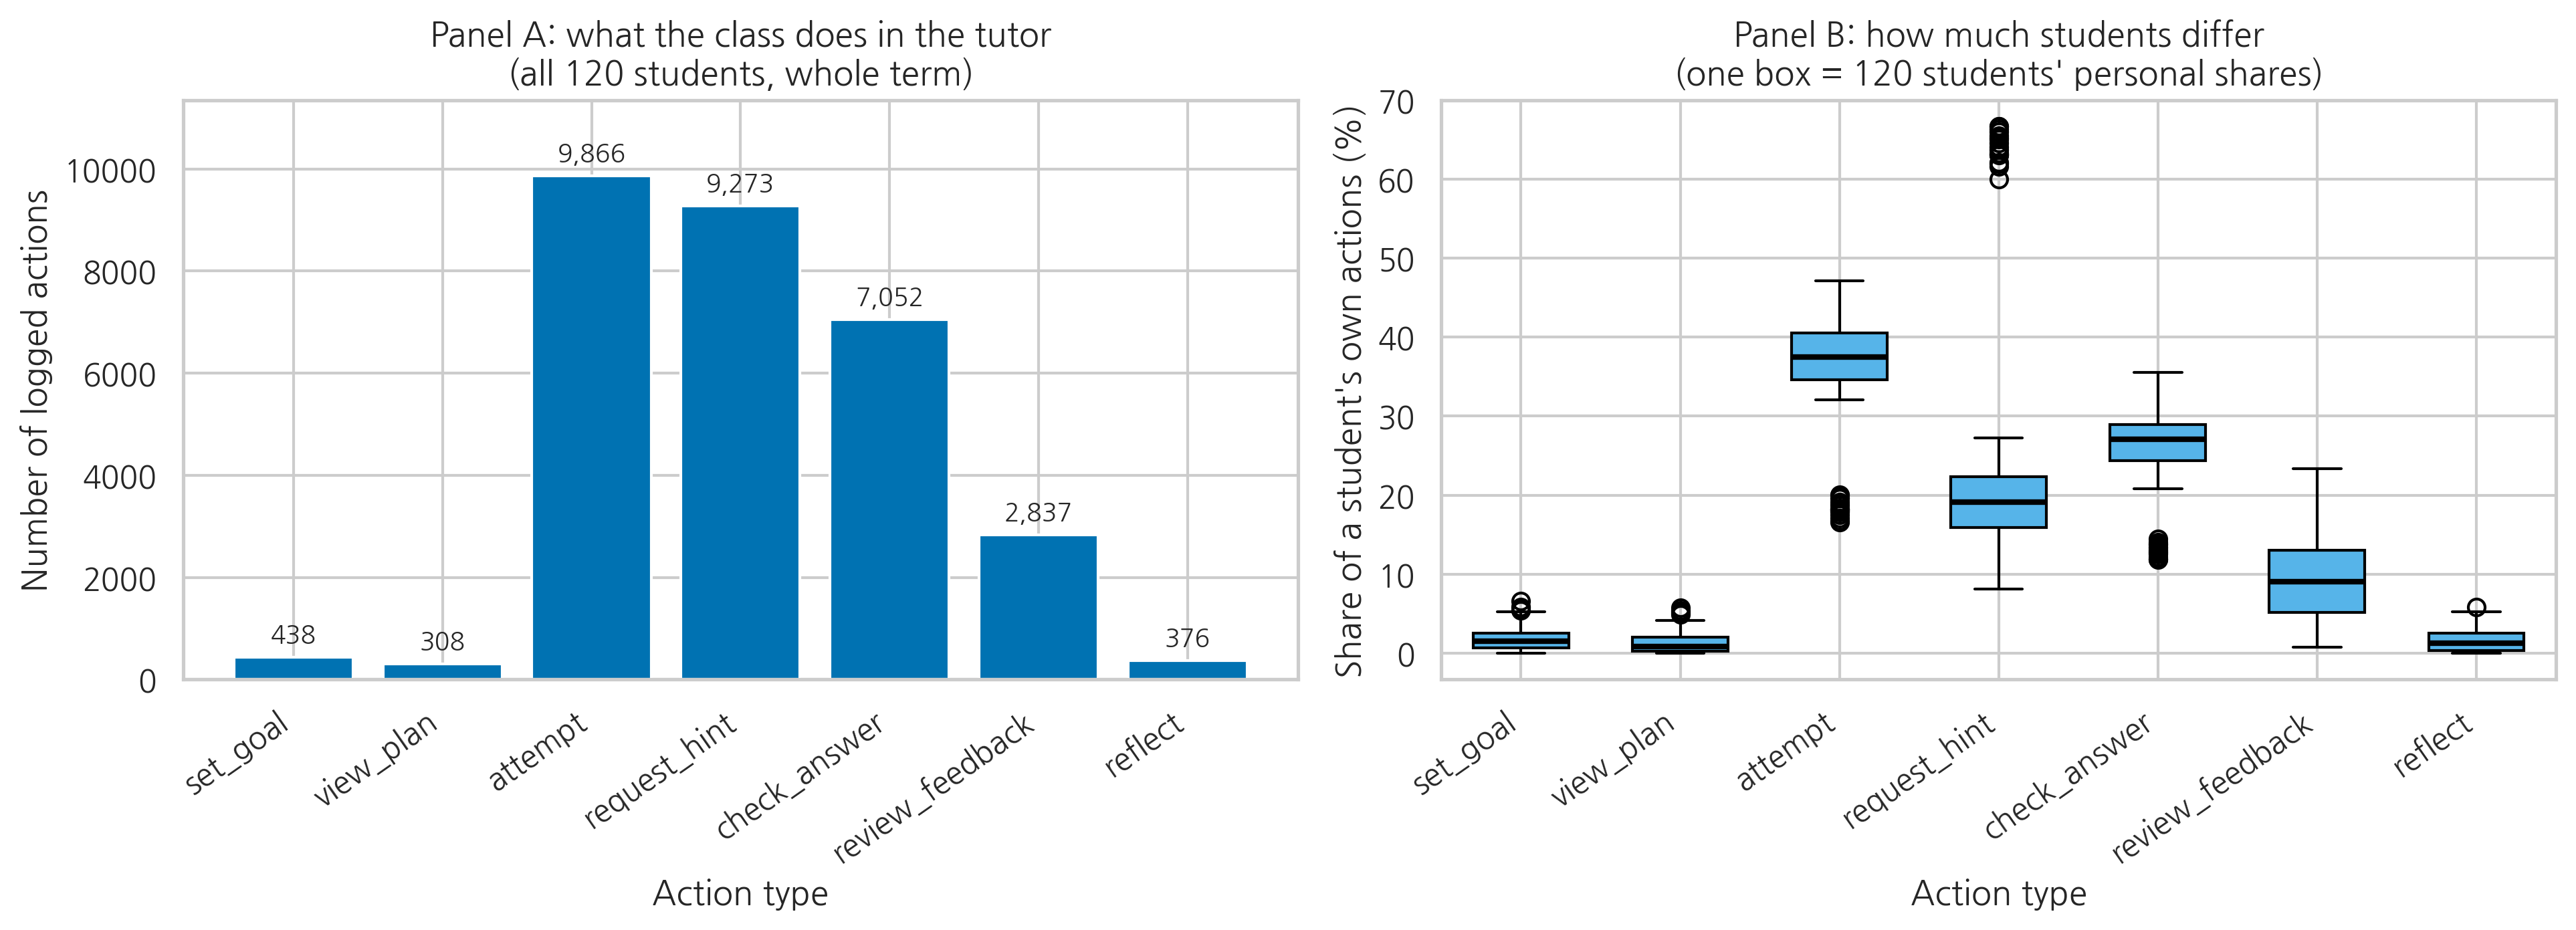

In [5]:
ACTIONS = ["set_goal", "view_plan", "attempt", "request_hint",
           "check_answer", "review_feedback", "reflect"]

# Per student: what share of that student's actions was each action type?
counts_by_student = (traces.groupby(["student_id", "action"]).size()
                     .unstack(fill_value=0)
                     .reindex(columns=ACTIONS, fill_value=0))
profile = counts_by_student.div(counts_by_student.sum(axis=1), axis=0)

print("Action frequency profile, first 5 students (share of that student's actions)")
print(profile.head().round(3).to_string())
print()
print("Spread across students, as percentages of a student's own actions")
spread = (profile.describe().loc[["min", "50%", "max"]] * 100).round(1)
print(spread.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

order = action_counts.reindex(ACTIONS)
axes[0].bar(range(len(ACTIONS)), order.values, color="#0072B2")
axes[0].set_xticks(range(len(ACTIONS)))
axes[0].set_xticklabels(ACTIONS, rotation=35, ha="right")
axes[0].set_ylabel("Number of logged actions")
axes[0].set_xlabel("Action type")
axes[0].set_title("Panel A: what the class does in the tutor\n(all 120 students, whole term)")
for i, v in enumerate(order.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontsize=9)
axes[0].set_ylim(0, order.max() * 1.15)

box_data = [profile[a].values * 100 for a in ACTIONS]
bp = axes[1].boxplot(box_data, vert=True, patch_artist=True, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor("#56B4E9")
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)
axes[1].set_xticks(range(1, len(ACTIONS) + 1))
axes[1].set_xticklabels(ACTIONS, rotation=35, ha="right")
axes[1].set_ylabel("Share of a student's own actions (%)")
axes[1].set_xlabel("Action type")
axes[1].set_title("Panel B: how much students differ\n(one box = 120 students' personal shares)")

plt.tight_layout()
plt.show()

**Interpretation prompt.** Panel A says `attempt` and `request_hint` dominate the log and `reflect` is rare. Panel B says the `request_hint` box is enormous: some students spend under 15 percent of their tutor time asking for hints and some spend over half.

Two questions to answer in a sentence each, before you scroll:

1. A dashboard vendor sells you Panel A as a "self-regulated learning report." What has Panel A actually measured?
2. `reflect` is the rarest action in the log. Name two reasons a student might never fire it, only one of which is about the student.

### ✏️ Your turn 1

Change `FOCUS_STUDENT` to any ID from `S001` to `S120` and rerun the cell to see that student's profile against the class median. The default works as is, so you can also just run it.

In [6]:
# ✏️ TODO: change this to any student ID from S001 to S120.
FOCUS_STUDENT = "S047"

focus = profile.loc[FOCUS_STUDENT] * 100
class_median = profile.median() * 100

comparison = pd.DataFrame({
    f"{FOCUS_STUDENT} (%)": focus.round(1),
    "class median (%)": class_median.round(1),
    "difference": (focus - class_median).round(1),
})
print(f"Action profile for {FOCUS_STUDENT}, compared with the class")
print(comparison.to_string())
print()
print("Total actions logged by this student:", int(counts_by_student.loc[FOCUS_STUDENT].sum()))
print("Tutor sessions attended            :",
      traces.loc[traces['student_id'] == FOCUS_STUDENT, 'session_id'].nunique())

Action profile for S047, compared with the class
                 S047 (%)  class median (%)  difference
action                                                 
set_goal              0.0               1.5        -1.5
view_plan             0.0               0.9        -0.9
attempt              16.6              37.5       -20.9
request_hint         64.1              19.1        45.0
check_answer         11.8              27.1       -15.3
review_feedback       7.3               9.0        -1.7
reflect               0.1               1.3        -1.2

Total actions logged by this student: 752
Tutor sessions attended            : 7


## 📊 2. A sequence detector, and what it detects

Profiles count actions. Regulation, as Winne describes it, is about **order**: setting a goal after you finish is not planning, and looking at feedback you never earned is not reflection. So we need a rule that reads sequences.

**Before we write it, one sentence to keep for the rest of the notebook.** What follows is a detector for a pattern in a log. It is not a detector for regulation. A session in which the pattern is absent is a session in which those three buttons were not pressed in that order, and there are many reasons for that which have nothing to do with whether the student planned, monitored, or evaluated anything. A student who planned on paper, or in their head, or with a roommate, leaves no trace here. **"No loop detected" is a statement about a log file. It is never a statement about a mind.**

Here is the rule we will use. Write it down and argue with it, because **Week 11 puts this lab back on the table** and asks who should have had a say in the labels it produced. A definition you cannot state out loud is a definition you cannot defend to the people it sorts.

### Definition: a complete regulation loop

> A tutor session contains a **complete regulation loop** when all three of the following happen **in this order** inside that session:
>
> 1. a `set_goal` action occurs,
> 2. an `attempt` occurs at some point **after** the `set_goal`, and
> 3. a `review_feedback` **or** a `reflect` action occurs at some point **after** that attempt.
>
> The three actions do **not** have to be next to each other. Any number of other actions may sit in between. What the rule cares about is the order: decide what you are doing, do it, then look back at how it went.
>
> A session either contains at least one instance of this sequence or it does not. The measure for a student is their **detected-loop rate**: the share of their logged tutor sessions in which the detector fires.
>
> Note the denominator: **logged sessions**, not eight. Students attended between 4 and 8 sessions, so for a student with 4 the rate can only take the values 0, 0.25, 0.5, 0.75 and 1, and one session flipping moves it by 25 points.

Three things this definition is doing, all of them arguable:

- It is a **coarse stand-in** for the recursive phase structure Winne describes, where learners define a task, plan, enact tactics, and then evaluate and adapt. Our `set_goal` stands in for planning, `attempt` for enacting, `review_feedback` or `reflect` for evaluating.
- It treats `review_feedback` and `reflect` as interchangeable closers. That is a choice, and you will get to change it in a moment.
- It ignores **how long** the sequence took. One that unfolds over twenty minutes and one that unfolds over twenty seconds both count. Hold that thought until Section 3.
- It can only see the seven buttons this tutor happens to have. A tutor with no `set_goal` button would score every student in the world at zero, and the measure would report it as an absence of regulation rather than an absence of a button. Winne's point about traces cuts in exactly this direction.

### Building the pattern matcher

The matcher below is a tiny state machine. It walks through a session's actions once, in order, and remembers how far along the pattern it has gotten. `stage = 0` means still waiting for a goal, `stage = 1` means the goal is set and we are waiting for an attempt, `stage = 2` means we are waiting for the loop to close.

You do not have to be able to write this. You do have to be able to say what it would do to a session you invented, which is what the demo prints.

In [7]:
LOOP_CLOSERS = ("review_feedback", "reflect")

def contains_loop_pattern(action_sequence, closers=LOOP_CLOSERS):
    """Return True if this ordered list of actions contains set_goal -> attempt -> closer.

    The three actions need not be adjacent; only their relative order matters.
    """
    stage = 0                        # 0 = need a goal, 1 = need an attempt, 2 = need a closer
    for action in action_sequence:
        if stage == 0 and action == "set_goal":
            stage = 1
        elif stage == 1 and action == "attempt":
            stage = 2
        elif stage == 2 and action in closers:
            return True
    return False

# Demo on hand-made sessions, so the rule is visible before we trust it on 844 real ones.
demos = [
    ["set_goal", "attempt", "check_answer", "review_feedback"],
    ["set_goal", "view_plan", "request_hint", "attempt", "check_answer", "reflect"],
    ["attempt", "check_answer", "review_feedback", "set_goal"],
    ["set_goal", "request_hint", "request_hint", "request_hint", "attempt"],
    ["attempt", "attempt", "attempt", "check_answer"],
]
print("Does this session contain a complete regulation loop?")
print("-" * 78)
for seq in demos:
    verdict = "YES" if contains_loop_pattern(seq) else "no "
    print(f"{verdict}  {' -> '.join(seq)}")

Does this session contain a complete regulation loop?
------------------------------------------------------------------------------
YES  set_goal -> attempt -> check_answer -> review_feedback
YES  set_goal -> view_plan -> request_hint -> attempt -> check_answer -> reflect
no   attempt -> check_answer -> review_feedback -> set_goal
no   set_goal -> request_hint -> request_hint -> request_hint -> attempt
no   attempt -> attempt -> attempt -> check_answer


**Read the demo, do not skip it.** Row 3 fails because the goal arrives last: the actions are all present, the order is wrong. Row 4 fails because the student never closed the loop, which is the most common way a real session falls short. If the rule surprises you anywhere, that is the moment to argue with it rather than with the results it produces later.

### Applying the matcher to all 844 real sessions

Now we run the same function over every student by session pair. The result is one row per session with a True or False, which we then average per student to get their loop rate.

In [8]:
# One row per session, holding the ordered list of actions in that session.
session_actions = (traces.groupby(["student_id", "session_id"])["action"]
                   .apply(list)
                   .reset_index()
                   .rename(columns={"action": "action_sequence"}))

session_actions["loop_pattern"] = session_actions["action_sequence"].apply(contains_loop_pattern)
session_actions["n_actions"] = session_actions["action_sequence"].apply(len)

detected_loop_rate = session_actions.groupby("student_id")["loop_pattern"].mean()
detected_loop_rate.name = "detected_loop_rate"

n_sessions = len(session_actions)
print(f"Tutor sessions analyzed            : {n_sessions}")
print(f"Sessions where the detector fired  : {session_actions['loop_pattern'].sum()}"
      f"  ({session_actions['loop_pattern'].mean():.1%})")
print()

# Where do the incomplete sessions break down? This is the diagnostic that matters.
has_goal = session_actions["action_sequence"].apply(lambda s: "set_goal" in s)
has_closer = session_actions["action_sequence"].apply(
    lambda s: any(a in LOOP_CLOSERS for a in s))
print("Why sessions do not fire the detector")
print(f"  no set_goal anywhere in the session : {(~has_goal).sum():>4}  ({(~has_goal).mean():.1%})")
print(f"  no closing action anywhere          : {(~has_closer).sum():>4}  ({(~has_closer).mean():.1%})")
wrong_order = int((has_goal & has_closer & ~session_actions['loop_pattern']).sum())
print(f"  has both, but in the wrong order    : {wrong_order:>4}")
print()

# The check that decides what this measure actually is.
same = bool((session_actions['loop_pattern'] == (has_goal & has_closer)).all())
print("Is 'the ordered sequence fired' the same set of sessions as")
print("'a set_goal appears somewhere AND a closer appears somewhere'?")
print("  ->", same)
print()
print("Detected-loop rate per student, summary")
print(detected_loop_rate.describe().round(3).to_string())
print()
print("Sessions each student actually attended (the denominator of that rate)")
print(traces.groupby('student_id')['session_id'].nunique()
      .value_counts().sort_index().rename('students').to_string())

Tutor sessions analyzed            : 844
Sessions where the detector fired  : 410  (48.6%)

Why sessions do not fire the detector
  no set_goal anywhere in the session :  406  (48.1%)
  no closing action anywhere          :   89  (10.5%)
  has both, but in the wrong order    :    0

Is 'the ordered sequence fired' the same set of sessions as
'a set_goal appears somewhere AND a closer appears somewhere'?
  -> True

Detected-loop rate per student, summary
count    120.000
mean       0.488
std        0.313
min        0.000
25%        0.250
50%        0.429
75%        0.723
max        1.000

Sessions each student actually attended (the denominator of that rate)
session_id
4     4
5     5
6    21
7    43
8    47


**🧠 Stop at that `True`.** It is the most important line the detector will print, and it is easy to walk past.

Zero sessions contain a goal and a closer in the wrong order. So on this log, "the ordered sequence `set_goal` then `attempt` then a closer fired" picks out **exactly** the same sessions as "a `set_goal` appears anywhere and a closer appears anywhere." The ordering requirement, which is the entire conceptual content of the word *loop*, **does no work at all here.**

Why? Because of how this tutor writes its log. `set_goal` can only be pressed when a session opens and `reflect` can only be pressed when it closes, so the order was never free to vary. Our sophisticated sequence matcher is, on this data, a two-item checklist wearing a sequence vocabulary.

That is not a bug in the code. It is the thing Viberg, Khalil, and Baars are pointing at when they ask how much learning analytics work on self-regulated learning measures self-regulated learning and how much of it measures activity in an SRL-shaped costume. **You will not know which one you have until you run this check**, and almost nobody runs it. Run it on your own sequence measures.

One consequence to carry forward: everything the rest of the notebook finds about "loops" would be found identically by counting whether two buttons were ever pressed. Whether that is still interesting is a real question, and the answer may well be yes. But it is a different claim from the one the section heading promised.


### Does any of this go with learning?

A detected-loop rate is just a behavior count until you connect it to something a teacher would care about. Our outcome is **quiz growth**: for each student we fit a straight line through their eight quiz scores and keep the slope. A slope of +1.0 means that student's scores rose by about one point per quiz across the term.

Growth, not average score, is the better outcome here. Average score mostly tells you who arrived well prepared. Slope asks whether the scores moved.

Two things that slope is not, and you should say both out loud before you use it.

- **It is not purely the student.** The eight quizzes are not equally hard, and this file records no difficulty parameter. Any drift in difficulty across the term lands inside every student's slope, and nothing here can pull the two apart.
- **This is synthetic data.** The tie between the loop pattern and growth exists because whoever wrote the generator wrote it in. Nothing below discovers a relationship; it recovers one that was planted. What is transferable is the *procedure*, not the coefficient.

In [9]:
quizzes = gradebook[gradebook["assessment"].str.startswith("quiz")].copy()
quizzes["quiz_number"] = quizzes["assessment"].str.replace("quiz_", "", regex=False).astype(int)

# Fit one straight line per student: score against quiz number. The slope is the growth rate.
slopes = {}
for student_id, one_student in quizzes.groupby("student_id"):
    one_student = one_student.sort_values("quiz_number")
    slope, intercept = np.polyfit(one_student["quiz_number"], one_student["score"], 1)
    slopes[student_id] = slope
quiz_slope = pd.Series(slopes, name="quiz_slope")

srl = pd.DataFrame({"detected_loop_rate": detected_loop_rate, "quiz_slope": quiz_slope}).dropna()
r_loop = srl["detected_loop_rate"].corr(srl["quiz_slope"])
rho_loop = srl["detected_loop_rate"].corr(srl["quiz_slope"], method="spearman")


def fisher_ci(r_value, n, z=1.96):
    """95% interval for a Pearson r, via Fisher's z transform."""
    zr = np.arctanh(r_value)
    se = 1.0 / np.sqrt(n - 3)
    return np.tanh(zr - z * se), np.tanh(zr + z * se)


lo_r, hi_r = fisher_ci(r_loop, len(srl))

print("Quiz growth slope, points gained per quiz")
print(quiz_slope.describe().round(2).to_string())
print()
print("Mean score on each quiz, which is the difficulty drift the slope cannot remove:")
print(quizzes.groupby("quiz_number")["score"].mean().round(1).to_string())
print()
print(f"Detected-loop rate against quiz growth: Pearson r = {r_loop:.2f} "
      f"[95% CI {lo_r:.2f} to {hi_r:.2f}], Spearman = {rho_loop:.2f}  (n = {len(srl)})")
print("Both are reported because the detected-loop rate is a proportion over a")
print("handful of sessions and lands on a few discrete values, which is not the")
print("well-behaved continuous variable a lone Pearson r quietly assumes.")
print()

srl["loop_group"] = pd.qcut(srl["detected_loop_rate"], 3, labels=["lowest third", "middle third", "highest third"])
table = srl.groupby("loop_group", observed=True)["quiz_slope"].agg(
    students="count", mean_growth="mean", sd="std").round(2)
print("Quiz growth by loop rate tercile")
print(table.to_string())

Quiz growth slope, points gained per quiz
count    120.00
mean       0.03
std        1.27
min       -3.38
25%       -1.03
50%        0.09
75%        0.85
max        3.08

Mean score on each quiz, which is the difficulty drift the slope cannot remove:
quiz_number
1    77.8
2    75.8
3    72.5
4    74.9
5    78.4
6    73.5
7    76.0
8    77.1

Detected-loop rate against quiz growth: Pearson r = 0.58 [95% CI 0.44 to 0.68], Spearman = 0.59  (n = 120)
Both are reported because the detected-loop rate is a proportion over a
handful of sessions and lands on a few discrete values, which is not the
well-behaved continuous variable a lone Pearson r quietly assumes.

Quiz growth by loop rate tercile
               students  mean_growth    sd
loop_group                                
lowest third         43        -0.82  1.17
middle third         39         0.14  0.96
highest third        38         0.88  1.04


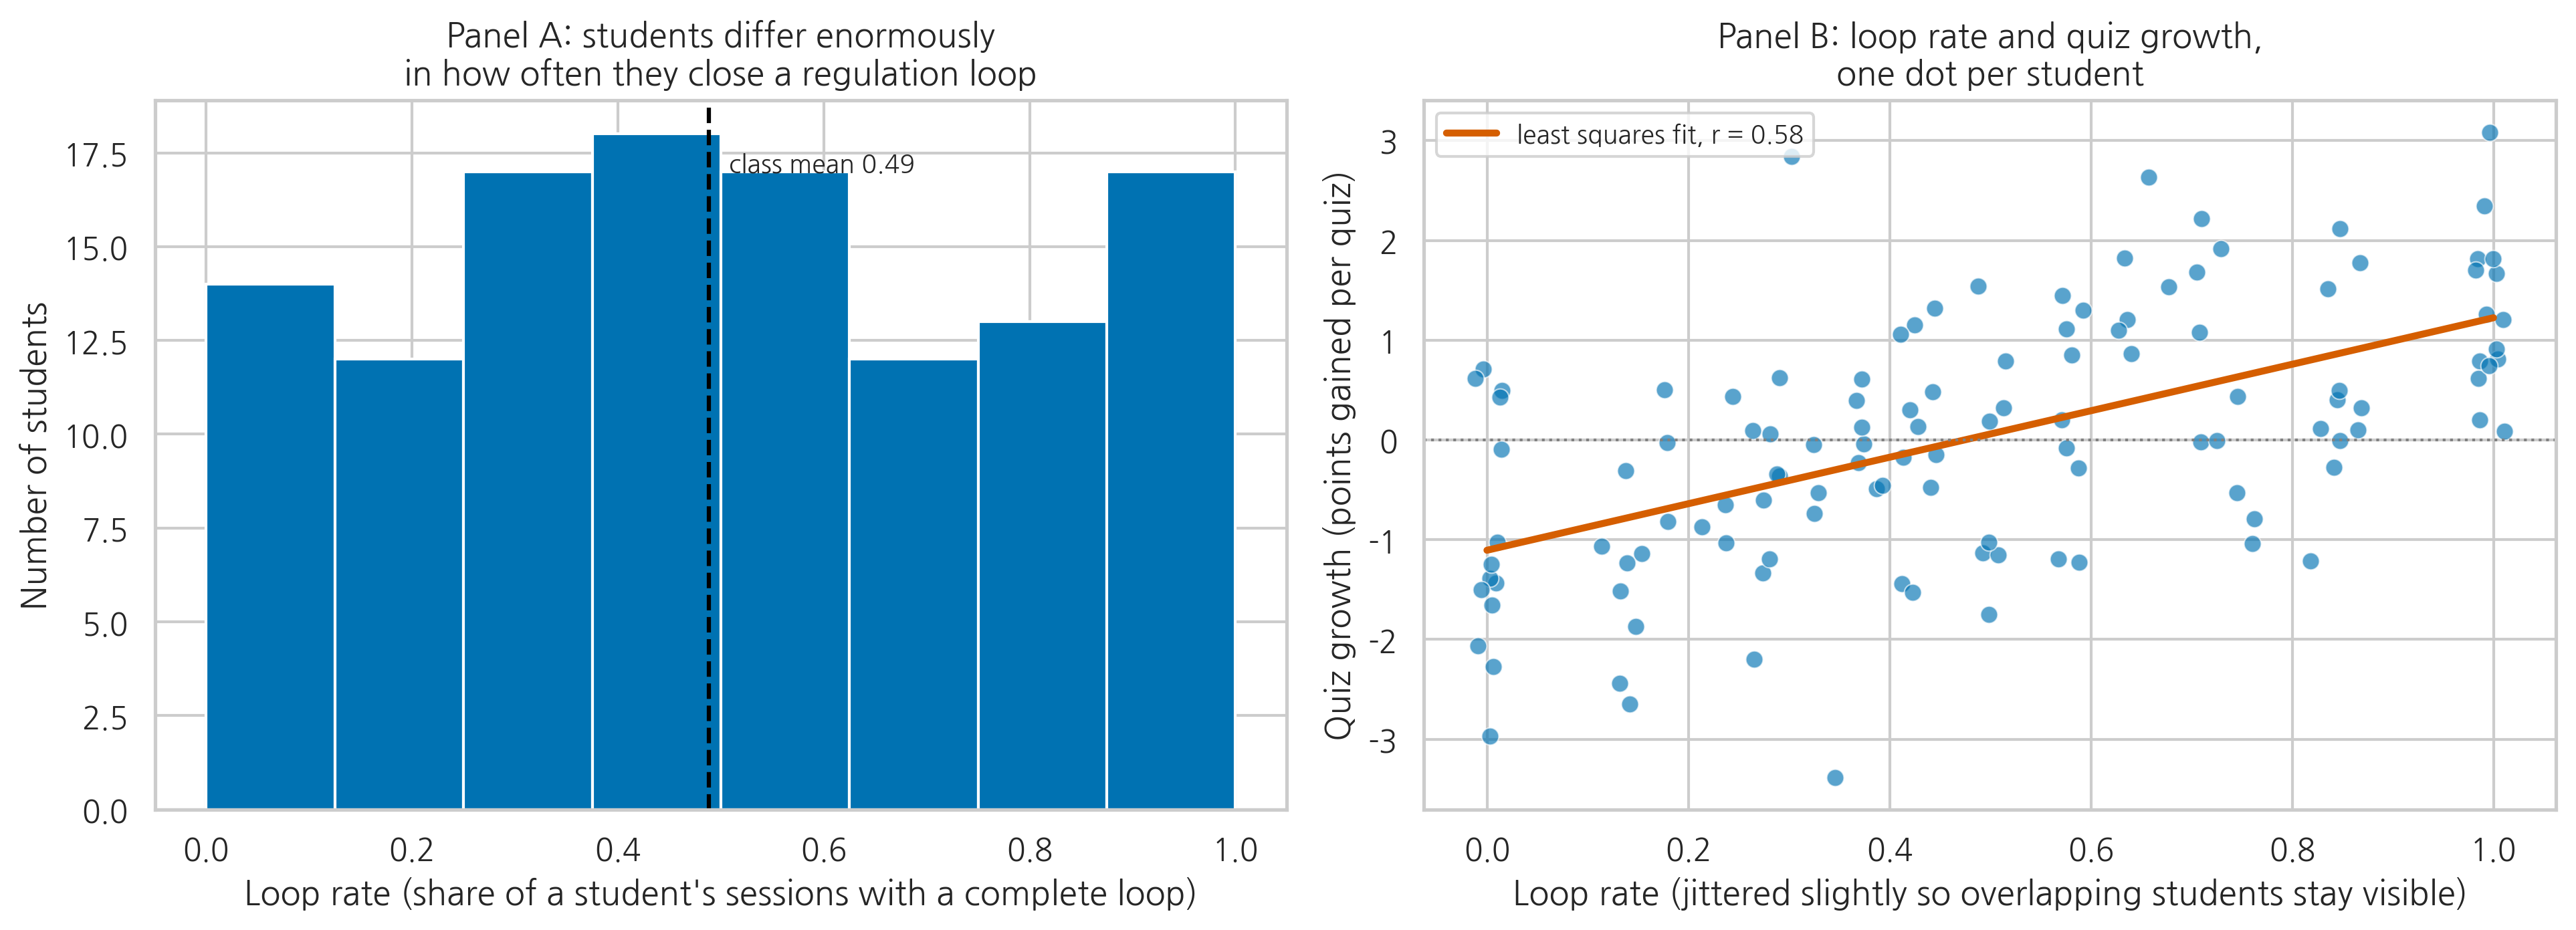

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(srl["detected_loop_rate"], bins=np.arange(0, 1.1, 0.125),
             color="#0072B2", edgecolor="white")
axes[0].set_xlabel("Loop rate (share of a student's sessions with a complete loop)")
axes[0].set_ylabel("Number of students")
axes[0].set_title("Panel A: students differ enormously\nin how often they close a regulation loop")
axes[0].axvline(srl["detected_loop_rate"].mean(), color="black", linestyle="--", linewidth=1.5)
axes[0].text(srl["detected_loop_rate"].mean() + 0.02, axes[0].get_ylim()[1] * 0.9,
             f"class mean {srl['detected_loop_rate'].mean():.2f}", fontsize=9)

# Loop rates land on a few discrete values (sessions are counted in whole numbers),
# so we nudge the points sideways a little to keep overlapping students visible.
rng = np.random.default_rng(8100)
jitter = rng.uniform(-0.018, 0.018, size=len(srl))
axes[1].scatter(srl["detected_loop_rate"] + jitter, srl["quiz_slope"],
                s=38, alpha=0.65, color="#0072B2", edgecolor="white", linewidth=0.5)
fit = np.polyfit(srl["detected_loop_rate"], srl["quiz_slope"], 1)
xs = np.linspace(0, 1, 50)
axes[1].plot(xs, np.polyval(fit, xs), color="#D55E00", linewidth=2.5,
             label=f"least squares fit, r = {r_loop:.2f}")
axes[1].axhline(0, color="grey", linewidth=1, linestyle=":")
axes[1].set_xlabel("Loop rate (jittered slightly so overlapping students stay visible)")
axes[1].set_ylabel("Quiz growth (points gained per quiz)")
axes[1].set_title("Panel B: loop rate and quiz growth,\none dot per student")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation prompt.** Panel B is a strong relationship and a noisy one: students at a loop rate of 0.75 span growth slopes from clearly negative to clearly positive. Answer these four:

1. Write the finding as a sentence you would be willing to defend in a dissertation proposal. Now write the version you would refuse to defend, the one with the word "because" in it.
2. A student whose detector never fires might be a student who pressed no goal button, or a student who planned somewhere the tutor cannot see, or a student for whom the goal button was the fifth thing on a page they never scrolled. **Only one of those three is about the student.** Which data would separate them, and could this tutor realistically collect it?
3. The dots at detected-loop rate 1.0 are not all thriving. What is that dispersion telling you about putting this number on a dashboard next to an individual student's name?
4. Four students attended only four sessions, so their rate moves 25 points if one session flips. Should a measure with that much quantization appear on a dashboard at all, and if it does, what has to appear beside it?

### ✏️ Your turn 2

The definition treats `review_feedback` and `reflect` as equally good ways to close a loop. That was a design decision, not a fact. Tighten it: make `reflect` the only acceptable closer, and see what happens to the loop rate and to the correlation with growth.

The default below is the strict version, so the cell runs as is. Change it back to `("review_feedback", "reflect")` to compare, or invent your own.

In [11]:
# ✏️ TODO: edit this tuple and rerun. Try ("reflect",) alone, then ("review_feedback", "reflect"),
# then something you can defend, like ("reflect", "view_plan").
MY_CLOSERS = ("reflect",)

my_loop = session_actions["action_sequence"].apply(
    lambda seq: contains_loop_pattern(seq, closers=MY_CLOSERS))
my_rate = my_loop.groupby(session_actions["student_id"]).mean()
my_r = my_rate.corr(quiz_slope)

print(f"Closers used                       : {MY_CLOSERS}")
print(f"Sessions counted as complete loops : {my_loop.sum()} of {len(my_loop)} ({my_loop.mean():.1%})")
print(f"Correlation with quiz growth       : r = {my_r:.2f}")
print()
print(f"For comparison, the notebook default {LOOP_CLOSERS}")
print(f"  complete loops: {session_actions['loop_pattern'].mean():.1%},  r = {r_loop:.2f}")
print()
print("If your r moved, ask why. A measurement decision just changed a finding.")

Closers used                       : ('reflect',)
Sessions counted as complete loops : 258 of 844 (30.6%)
Correlation with quiz growth       : r = 0.52

For comparison, the notebook default ('review_feedback', 'reflect')
  complete loops: 48.6%,  r = 0.58

If your r moved, ask why. A measurement decision just changed a finding.


## 📊 3. Runs of rapid hint requests, and why counting will not find them

The field has a name for what this section is about. It calls it **"hint spam"**, or **"gaming the system"**, and the phrases appear in the titles of well-cited papers. Hold them at arm's length for a moment and look at what they do. Both name a motive: they say the student is abusing the tutor rather than using it. Neither is anything a log file can see. Somebody chose that vocabulary, and the choice arrived before the evidence did.

We are going to study exactly the same behaviour and call it what the log can actually support: **a run of hint requests a few seconds apart.** That is a description of a timestamp column. Whether it constitutes abuse, panic, boredom, a broken hint interface, or the fastest available route to an answer the student had no other way to reach, is precisely the open question, and it is the question the course is here to keep open.

So: asking for a lot of hints can mean a student is stuck and seeking help, which is a regulation strategy rather than a failure of one. It can also mean a student is pressing the hint button until the tutor gives away the answer, which is a rational response to a badly designed tutor as often as it is anything else. **The counts look identical. Only the clock separates them, and even the clock does not supply a motive.**

So we compute the gap in seconds between each action and the one before it, within the same session, and look at what happens right before a hint request.

Seconds between the previous action and a hint request
count    9043.0
mean       18.0
std        20.7
min         1.0
10%         3.0
25%         4.0
50%         8.0
75%        22.0
90%        52.0
max        95.0

Hint requests arriving within 5 seconds of the previous action : 29.7%
Hint requests arriving within 10 seconds                       : 51.9%


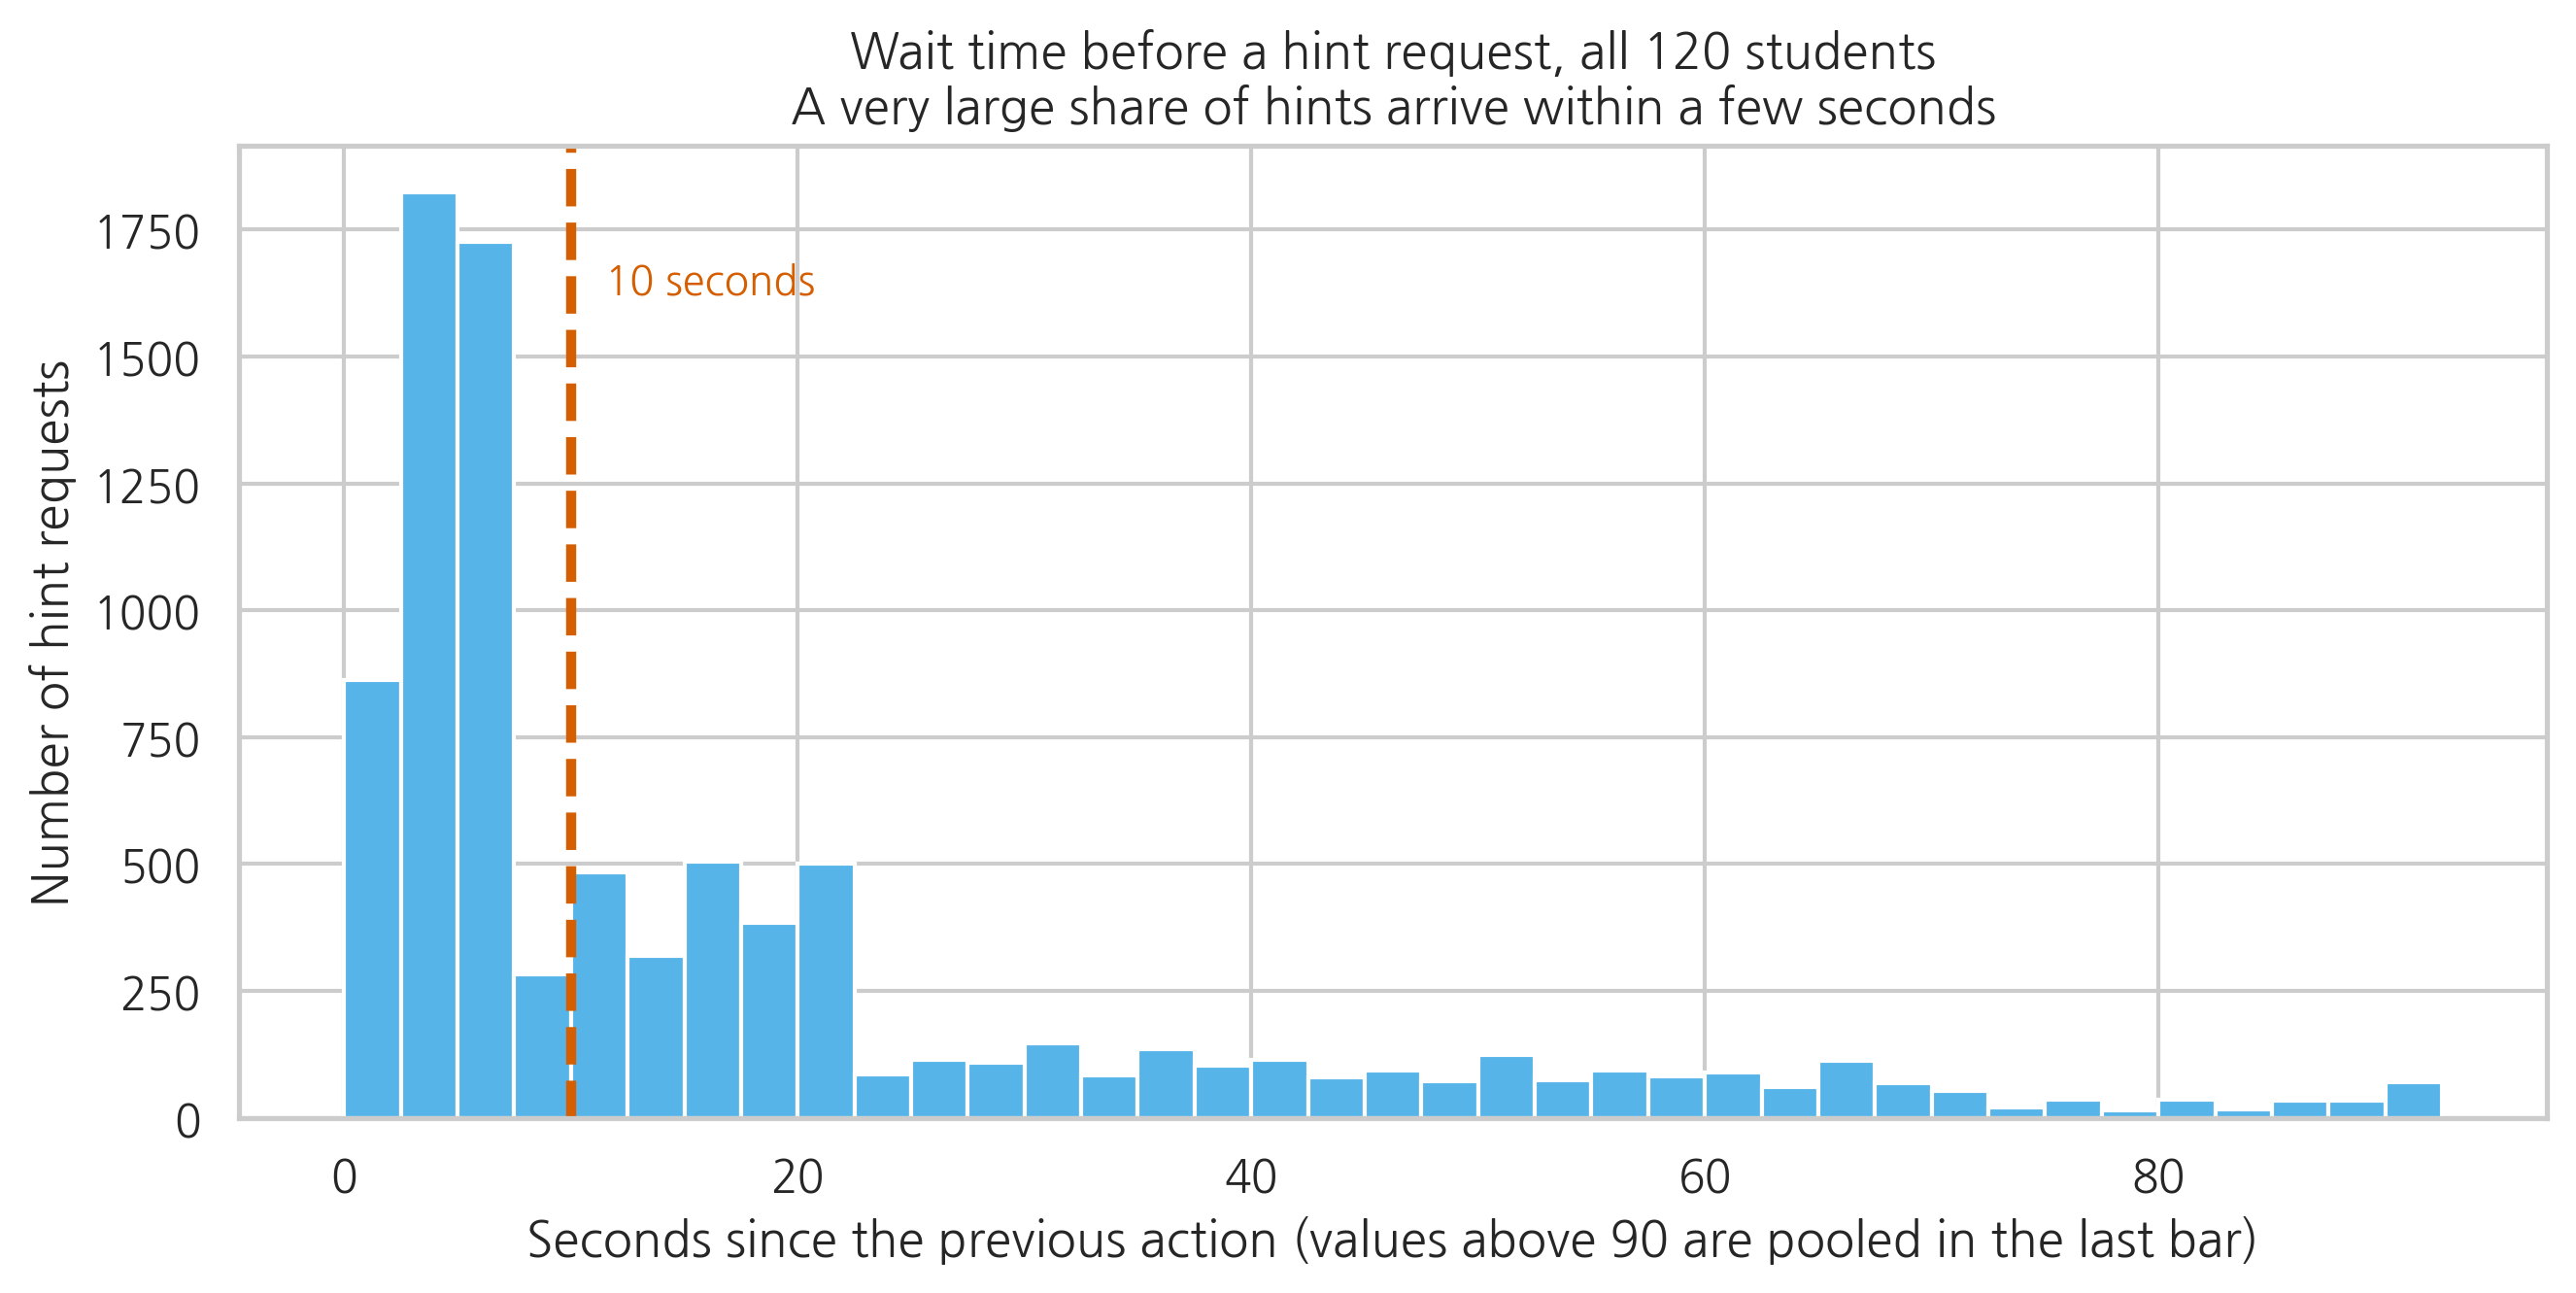

In [12]:
# Seconds since the previous action, computed within a session so we never
# measure across a two week break between sessions.
traces["gap_s"] = (traces.groupby(["student_id", "session_id"])["timestamp"]
                   .diff().dt.total_seconds())
traces["previous_action"] = (traces.groupby(["student_id", "session_id"])["action"]
                             .shift(1))

hint_gaps = traces.loc[traces["action"] == "request_hint", "gap_s"].dropna()

print("Seconds between the previous action and a hint request")
print(hint_gaps.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1).to_string())
print()
print(f"Hint requests arriving within 5 seconds of the previous action : {(hint_gaps < 5).mean():.1%}")
print(f"Hint requests arriving within 10 seconds                       : {(hint_gaps < 10).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(hint_gaps.clip(upper=90), bins=np.arange(0, 95, 2.5),
        color="#56B4E9", edgecolor="white")
ax.axvline(10, color="#D55E00", linewidth=2.5, linestyle="--")
ax.text(11.5, ax.get_ylim()[1] * 0.85, "10 seconds", color="#D55E00", fontsize=10)
ax.set_xlabel("Seconds since the previous action (values above 90 are pooled in the last bar)")
ax.set_ylabel("Number of hint requests")
ax.set_title("Wait time before a hint request, all 120 students\nA very large share of hints arrive within a few seconds")
plt.tight_layout()
plt.show()

**Interpretation prompt.** This distribution has a tall spike near zero and then thins out. Note the ceiling before you describe it as a long tail: nothing in this file exceeds 95 seconds, because the simulator that wrote it never draws a longer gap. A real tutor log would have a genuinely long tail, containing the student who left for twenty minutes, and every conclusion you might draw about "thinking time" would have to survive that tail.

Before reading on: is the spike near zero a problem, or is it what fast, fluent practice looks like? Name the extra column that would settle it, and say whether a tutor could realistically log it without watching the student more closely than you would want to be watched.

### A rule, and its price

A single fast hint is nothing. Someone reads a problem, recognizes it as unfamiliar, and asks. What is not nothing is a **run** of them.

> **Rapid hint run**: three or more consecutive `request_hint` actions in the same session, where each one arrives within 10 seconds of the action before it.
>
> A student's log is flagged for **repeated rapid hint runs** if it contains at least 3 such runs across the term.

Read the wording of that second line carefully, because it is doing deliberate work. The flag is attached to **a log**, not to a person, and the name says what was counted rather than what it means. Compare it with the sentence the field would write, "the student is a hint spammer," and notice how much that version claims and how little of it the data supplies.

Three things about the rule that are ours and not the data's:

- **10 seconds** is a number we picked.
- **3 in a row** is a number we picked.
- **3 runs across the term** is a number we picked, and it is a *count*, not a rate, even though students attended between 4 and 8 sessions. A student who attended 8 sessions has twice as many chances to accumulate three runs as one who attended 4. That is a defect in our rule. It is left in, visible, because you will meet it in your own work.

You will get to move all three in a minute, and you should.

In [13]:
RAPID_GAP_SECONDS = 10   # a hint arriving faster than this counts as "rapid"
MIN_RUN_LENGTH   = 3     # this many rapid hints in a row makes one run
MIN_RUNS_TO_FLAG = 3     # this many runs across the term flags the log

# A "rapid repeat" is a hint request that follows another hint request very quickly.
traces["rapid_repeat_hint"] = (
    (traces["action"] == "request_hint") &
    (traces["previous_action"] == "request_hint") &
    (traces["gap_s"] < RAPID_GAP_SECONDS)
)

def count_runs(flags, min_length=MIN_RUN_LENGTH):
    """Count runs of rapid repeats. A run of k hints contains k-1 rapid repeats in a row."""
    needed = min_length - 1
    runs, current = 0, 0
    for is_rapid in flags:
        if is_rapid:
            current += 1
        else:
            if current >= needed:
                runs += 1
            current = 0
    if current >= needed:
        runs += 1
    return runs

rapid_hint_runs = traces.groupby("student_id")["rapid_repeat_hint"].apply(count_runs)
rapid_hint_runs.name = "rapid_hint_runs"

sessions_attended = traces.groupby("student_id")["session_id"].nunique()
hints_total = (traces[traces["action"] == "request_hint"].groupby("student_id").size()
               .reindex(rapid_hint_runs.index, fill_value=0))
hints_per_session = (hints_total / sessions_attended).rename("hints_per_session")
median_wait = (traces[traces["action"] == "request_hint"]
               .groupby("student_id")["gap_s"].median().rename("median_wait_s"))

rapid_hint_flag = (rapid_hint_runs >= MIN_RUNS_TO_FLAG).rename("rapid_hint_flag")

print(f"Logs flagged for repeated rapid hint runs: {rapid_hint_flag.sum()} of {len(rapid_hint_flag)}")
print()
summary = pd.DataFrame({
    "students": [(~rapid_hint_flag).sum(), rapid_hint_flag.sum()],
    "mean hints per session": [hints_per_session[~rapid_hint_flag].mean(),
                               hints_per_session[rapid_hint_flag].mean()],
    "mean median wait (s)": [median_wait[~rapid_hint_flag].mean(),
                             median_wait[rapid_hint_flag].mean()],
    "mean rapid runs": [rapid_hint_runs[~rapid_hint_flag].mean(),
                        rapid_hint_runs[rapid_hint_flag].mean()],
}, index=["not flagged", "flagged"]).round(1)
print(summary.to_string())
print()
print("Sessions attended, by whether the log was flagged. Check this before you")
print("trust a rule that counts across a term rather than per session:")
print(pd.DataFrame({
    "mean sessions attended": [sessions_attended[~rapid_hint_flag].mean(),
                               sessions_attended[rapid_hint_flag].mean()],
    "min sessions attended": [sessions_attended[~rapid_hint_flag].min(),
                              sessions_attended[rapid_hint_flag].min()],
}, index=["not flagged", "flagged"]).round(2).to_string())

Logs flagged for repeated rapid hint runs: 18 of 120

             students  mean hints per session  mean median wait (s)  mean rapid runs
not flagged       102                     5.9                  21.4              0.0
flagged            18                    40.0                   4.3             54.0

Sessions attended, by whether the log was flagged. Check this before you
trust a rule that counts across a term rather than per session:
             mean sessions attended  min sessions attended
not flagged                    7.00                      4
flagged                        7.22                      6


### The two students the counts cannot separate

The table above is an average. Averages are where evidence goes to hide. So look at two actual students:

- **S017** is the heaviest hint user in the whole class who was *not* flagged.
- **S072** is the *lightest* hint user among the flagged students.

If hint counts were enough, these two would be neighbors. Watch the clock instead.

In [14]:
def hint_portrait(student_id):
    print(f"{student_id}: {hints_per_session[student_id]:.1f} hints per session, "
          f"median wait before a hint {median_wait[student_id]:.0f} s, "
          f"{rapid_hint_runs[student_id]} rapid runs, "
          f"flagged = {bool(rapid_hint_flag[student_id])}")

hint_portrait("S017")
hint_portrait("S072")
print()

def show_hint_window(student_id, session_id, n_rows=14):
    one = traces[(traces["student_id"] == student_id) &
                 (traces["session_id"] == session_id)]
    view = one[["action", "item_id", "gap_s"]].head(n_rows).rename(
        columns={"gap_s": "seconds_since_previous"})
    print(f"--- {student_id}, {session_id} ---")
    print(view.to_string(index=False))
    print()

show_hint_window("S017", "tutor_1")
show_hint_window("S072", "tutor_4")

S017: 14.2 hints per session, median wait before a hint 21 s, 0 rapid runs, flagged = False
S072: 21.0 hints per session, median wait before a hint 4 s, 33 rapid runs, flagged = True

--- S017, tutor_1 ---
         action    item_id  seconds_since_previous
   request_hint w1_item_01                     NaN
        attempt w1_item_01                    22.0
   check_answer w1_item_01                    82.0
review_feedback w1_item_01                    12.0
   request_hint w1_item_01                    60.0
        attempt w1_item_01                    18.0
   request_hint w1_item_01                    56.0
        attempt w1_item_01                    32.0
   check_answer w1_item_01                    65.0
   request_hint w1_item_02                    22.0
        attempt w1_item_02                    37.0
   check_answer w1_item_02                    60.0
review_feedback w1_item_02                    15.0
   request_hint w1_item_02                    13.0

--- S072, tutor_4 ---
      

**Interpretation prompt.** S017 asks for a lot of hints and waits 20 seconds or more before most of them, threaded between attempts and feedback. S072 fires six hints in nineteen seconds and then attempts.

The obvious next sentence is "nobody reads a hint in three seconds." Resist it for a moment, because it is an assertion about a person made from a timestamp, and this course is about noticing when you are doing that.

**What would put someone in front of that item, pressing hint six times in nineteen seconds?** Write down as many candidates as you can before you settle on one. Here are five to start, and only the last is about the student:

1. **The item.** Look at the `item_id` column: those six hints are all on the same problem. The student has hit something they cannot start. If the item is badly scaffolded, or assumes a prerequisite the course never taught, this is what that looks like in a log.
2. **The hint design.** Many tutors deliver hints in a graduated stack, where the first two are near-useless restatements and only the last one is concrete. If the fastest route to a usable hint is to press through the stack, then a run of rapid presses is the tutor's own interface working as designed, and calling it abuse blames the student for reading the manual.
3. **The absence of any other way to get unstuck.** There is no `ask_teacher` button in this tutor, no `mark_this_confusing`, no way to say "I do not understand the question." The hint button is the only exit from being stuck. When a system provides one door, do not be surprised that people use it.
4. **The stakes and the clock.** A quiz deadline is on Tuesday. The cheapest way to finish is not always the way that teaches most, and a student rationing scarce hours across five courses is optimizing something real.
5. **The student's own strategy.** Perhaps they are skipping ahead deliberately, or already know this material, or have decided this item is not worth their time. That is also a self-regulatory act, just not one the rubric rewards.

Now write two sentences. First, describe what the *log* shows for each student, using no word that implies a motive. Second, write the sentence a dashboard would have put in front of a teacher if it reported only "hints requested this week", and say which of the five explanations above that dashboard has silently ruled out.

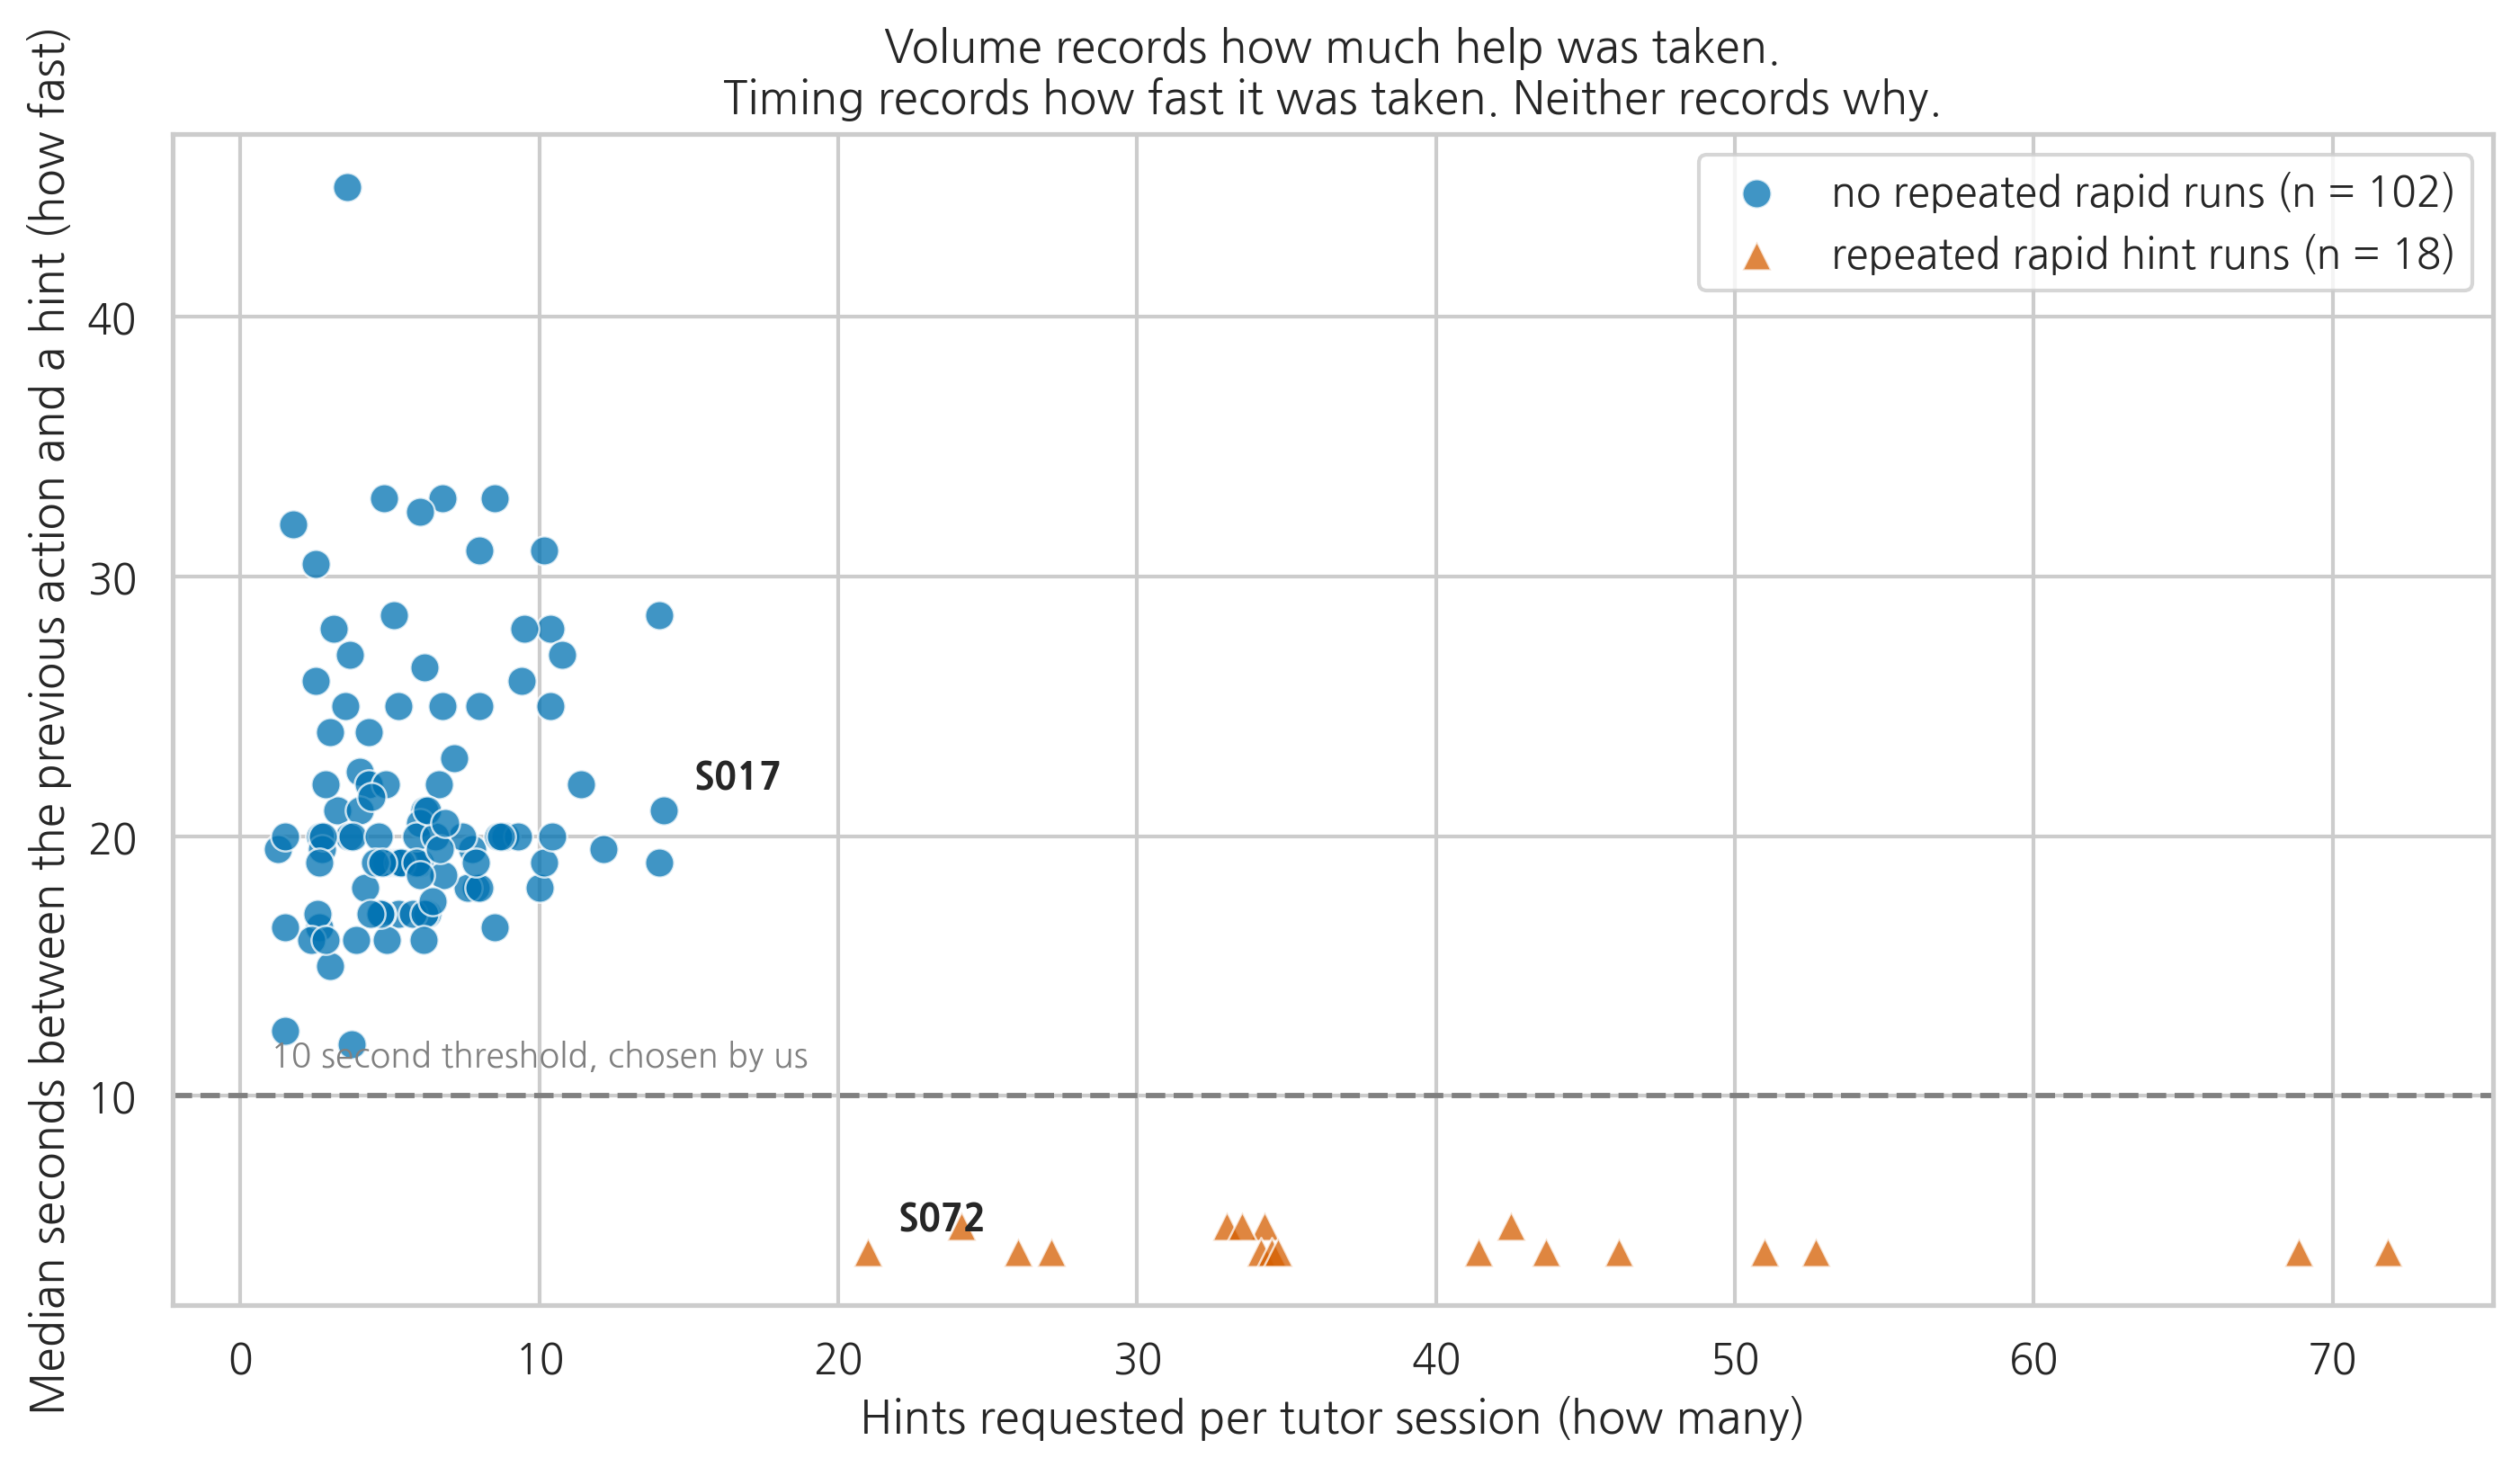

In [15]:
hint_profile = pd.concat([hints_per_session, median_wait, rapid_hint_runs, rapid_hint_flag], axis=1)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for flagged, colour, marker, label in [
    (False, "#0072B2", "o", f"no repeated rapid runs (n = {(~rapid_hint_flag).sum()})"),
    (True, "#D55E00", "^", f"repeated rapid hint runs (n = {rapid_hint_flag.sum()})"),
]:
    part = hint_profile[hint_profile["rapid_hint_flag"] == flagged]
    ax.scatter(part["hints_per_session"], part["median_wait_s"],
               s=60, alpha=0.75, color=colour, marker=marker,
               edgecolor="white", linewidth=0.6, label=label)

ax.axhline(RAPID_GAP_SECONDS, color="grey", linestyle="--", linewidth=1.4)
ax.text(1, RAPID_GAP_SECONDS + 1.2, f"{RAPID_GAP_SECONDS} second threshold, chosen by us",
        fontsize=9, color="grey")
for sid in ["S017", "S072"]:
    ax.annotate(sid, (hint_profile.loc[sid, "hints_per_session"],
                      hint_profile.loc[sid, "median_wait_s"]),
                textcoords="offset points", xytext=(8, 6), fontsize=10, weight="bold")
ax.set_xlabel("Hints requested per tutor session (how many)")
ax.set_ylabel("Median seconds between the previous action and a hint (how fast)")
ax.set_title("Volume records how much help was taken.\nTiming records how fast it was taken. Neither records why.")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation prompt.** The two groups separate cleanly on the vertical axis: every flagged log has a median wait of 5 seconds or less, every unflagged log has a median of at least 12.

Be careful, because in *this* dataset the two groups also separate on the horizontal axis (the flagged logs start at 21 hints per session, the unflagged ones stop at 14.2). An analyst who only counted hints would have produced roughly the right list of students this time. That is luck, and it is luck manufactured by a simulator that made the planted pattern extreme. Do not carry it anywhere.

1. Describe a real tutoring system in which the horizontal separation would vanish while the vertical separation stayed. Which students would a count-only rule then miss?
2. Now the harder direction, and the one the course cares about most. **Who does a timing rule wrongly catch?** A student on a shared laptop whose sibling clicks through. A student using a screen reader that fires the hint request before the text is spoken. A student who already knows the material and is skimming. A student on a phone with a mis-registering touch target. For each, say what would have to be known before this flag is allowed to reach a teacher, and who would have to collect it.
3. Suppose you cannot get any of that. Write the one-line note you would attach to the flag so that a teacher who sees it does the right thing anyway. If you cannot write that note, you have your answer about whether the flag should ship.

### ✏️ Your turn 3

Move the thresholds. This is the most consequential cell in the notebook, because it shows how much of a "finding" is a decision somebody made.

**The cell ships with a rule that is deliberately different from the notebook's**, 4 hints in a row within 3 seconds, so that you see the label move before you touch anything. Then put it back to 10 seconds and 3 in a row and watch it move again. Try 5 seconds. Try 2 in a row. Try `MY_MIN_RUNS = 1`.

The question to hold: which of these rules would you be willing to defend to the eighteen students it names, and on what grounds?

In [16]:
# ✏️ TODO: change one number at a time and rerun.
# Ships as a STRICTER rule than the notebook's, so you can see a label move.
MY_GAP_SECONDS = 3      # notebook default is 10. Try 5, then 10, then 30.
MY_RUN_LENGTH  = 4      # notebook default is 3. Try 2, then 3, then 5.
MY_MIN_RUNS    = 3      # notebook default is 3. Try 1, then 10.

my_rapid = ((traces["action"] == "request_hint") &
            (traces["previous_action"] == "request_hint") &
            (traces["gap_s"] < MY_GAP_SECONDS))
my_runs = my_rapid.groupby(traces["student_id"]).apply(
    lambda flags: count_runs(flags, min_length=MY_RUN_LENGTH))
my_flag = my_runs >= MY_MIN_RUNS

print(f"Your rule    : {MY_RUN_LENGTH}+ hints in a row, each within {MY_GAP_SECONDS} s, "
      f"at least {MY_MIN_RUNS} runs across the term")
print(f"Notebook rule: {MIN_RUN_LENGTH}+ hints in a row, each within {RAPID_GAP_SECONDS} s, "
      f"at least {MIN_RUNS_TO_FLAG} runs across the term")
print()
print(f"Logs flagged by your rule    : {my_flag.sum()} of {len(my_flag)}")
print(f"Logs flagged by the notebook : {rapid_hint_flag.sum()} of {len(rapid_hint_flag)}")
print(f"Students classified the same way by both: {(my_flag == rapid_hint_flag).mean():.1%}")
changed = rapid_hint_flag.index[my_flag != rapid_hint_flag].tolist()
print(f"Students whose label changed : "
      f"{len(changed)}" + (f"  {changed[:12]}{' ...' if len(changed) > 12 else ''}" if changed else ""))
print()
print("Those are real students in this fictional class, and the only thing that")
print("moved between the two lists is a number nobody outside this notebook agreed to.")
print("A flag that swings when you move a threshold by seven seconds is a hypothesis,")
print("not a finding, and it is certainly not a description of anybody.")

Your rule    : 4+ hints in a row, each within 3 s, at least 3 runs across the term


Notebook rule: 3+ hints in a row, each within 10 s, at least 3 runs across the term

Logs flagged by your rule    : 1 of 120
Logs flagged by the notebook : 18 of 120
Students classified the same way by both: 85.8%
Students whose label changed : 17  ['S001', 'S007', 'S009', 'S010', 'S012', 'S019', 'S025', 'S041', 'S047', 'S062', 'S066', 'S072'] ...

Those are real students in this fictional class, and the only thing that
moved between the two lists is a number nobody outside this notebook agreed to.
A flag that swings when you move a threshold by seven seconds is a hypothesis,
not a finding, and it is certainly not a description of anybody.


## 📊 4. Putting the two log patterns next to learning

We now have two measures derived from the log: a detected-loop rate and a rapid-hint-run flag. Sort every student into one of three groups and compare quiz growth.

The group names below are deliberately clumsy. They describe **what was found in a log file**, because a name leaves this notebook the moment somebody screenshots the chart, and at that point "hint spammers" becomes a description of eighteen named people that no evidence here supports.

- **`loop pattern in half or more sessions`**: not flagged for rapid runs, and the loop detector fired in at least half of their logged sessions.
- **`loop pattern in under half of sessions`**: not flagged, detector fired less often.
- **`repeated rapid hint runs`**: flagged by the run rule.

Look at the chart before you read the prose under it.

In [17]:
srl["rapid_hint_flag"] = rapid_hint_flag.reindex(srl.index).fillna(False)
srl["rapid_hint_runs"] = rapid_hint_runs.reindex(srl.index).fillna(0)

G_RAPID = "repeated rapid hint runs"
G_LOW   = "loop pattern in under half of sessions"
G_HIGH  = "loop pattern in half or more sessions"

def label_profile(row):
    """Name what the log contains. Never name what the student is."""
    if row["rapid_hint_flag"]:
        return G_RAPID
    if row["detected_loop_rate"] >= 0.5:
        return G_HIGH
    return G_LOW

srl["profile"] = srl.apply(label_profile, axis=1)
GROUP_ORDER = [G_RAPID, G_LOW, G_HIGH]

group_table = (srl.groupby("profile")[["quiz_slope", "detected_loop_rate"]]
               .agg(["count", "mean", "std"])
               .loc[GROUP_ORDER].round(2))
group_table.columns = ["n", "mean growth", "sd growth", "n2", "mean loop rate", "sd loop rate"]
print("Quiz growth and detected-loop rate by log profile")
print(group_table[["n", "mean growth", "sd growth", "mean loop rate"]].to_string())
print()


def cohens_d(a, b):
    """Standardized mean difference with a DEGREES-OF-FREEDOM WEIGHTED pooled SD.

    The unweighted version, sqrt((var_a + var_b) / 2), is only correct when the
    two groups are the same size. Here one comparison is 18 against 102, so the
    unweighted form would give the 18-student group the same say as the 102, and
    would report -0.57 where the correct value is -0.55. Small here. Not always.
    """
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled


def cohens_d_ci(a, b, z=1.96):
    """95% interval for d, large-sample approximation."""
    na, nb = len(a), len(b)
    d = cohens_d(a, b)
    se = np.sqrt((na + nb) / (na * nb) + d ** 2 / (2 * (na + nb)))
    return d - z * se, d + z * se


def report(name, a, b):
    d = cohens_d(a, b)
    lo, hi = cohens_d_ci(a, b)
    print(f"{name:<58} d = {d:+.2f}  [95% CI {lo:+.2f}, {hi:+.2f}]   n = {len(a)} vs {len(b)}")


rapid   = srl.loc[srl["profile"] == G_RAPID, "quiz_slope"]
low     = srl.loc[srl["profile"] == G_LOW,   "quiz_slope"]
high    = srl.loc[srl["profile"] == G_HIGH,  "quiz_slope"]
not_flagged = srl.loc[~srl["rapid_hint_flag"], "quiz_slope"]
not_high    = srl.loc[srl["profile"] != G_HIGH, "quiz_slope"]

print("Three comparisons. The denominator is the whole argument, so it is printed.")
report("rapid-run logs vs ALL logs not flagged (loops included)", rapid, not_flagged)
report("rapid-run logs vs UNFLAGGED, low-loop logs only",         rapid, low)
report("high-loop logs vs everyone else",                          high, not_high)
print()
print("Read the second line, not the first. Against the students who are simply")
print("not flagged and whose detector fires less than half the time, the rapid-run")
print("group's growth is indistinguishable from zero difference, and the interval")
print("is wide enough to contain a moderate effect in either direction.")

Quiz growth and detected-loop rate by log profile
                                         n  mean growth  sd growth  mean loop rate
profile                                                                           
repeated rapid hint runs                18        -0.55       1.10            0.20
loop pattern in under half of sessions  44        -0.56       1.15            0.25
loop pattern in half or more sessions   58         0.66       1.10            0.76

Three comparisons. The denominator is the whole argument, so it is printed.
rapid-run logs vs ALL logs not flagged (loops included)    d = -0.54  [95% CI -1.05, -0.04]   n = 18 vs 102
rapid-run logs vs UNFLAGGED, low-loop logs only            d = +0.01  [95% CI -0.54, +0.56]   n = 18 vs 44
high-loop logs vs everyone else                            d = +1.09  [95% CI +0.71, +1.48]   n = 58 vs 62

Read the second line, not the first. Against the students who are simply
not flagged and whose detector fires less than half the time, 

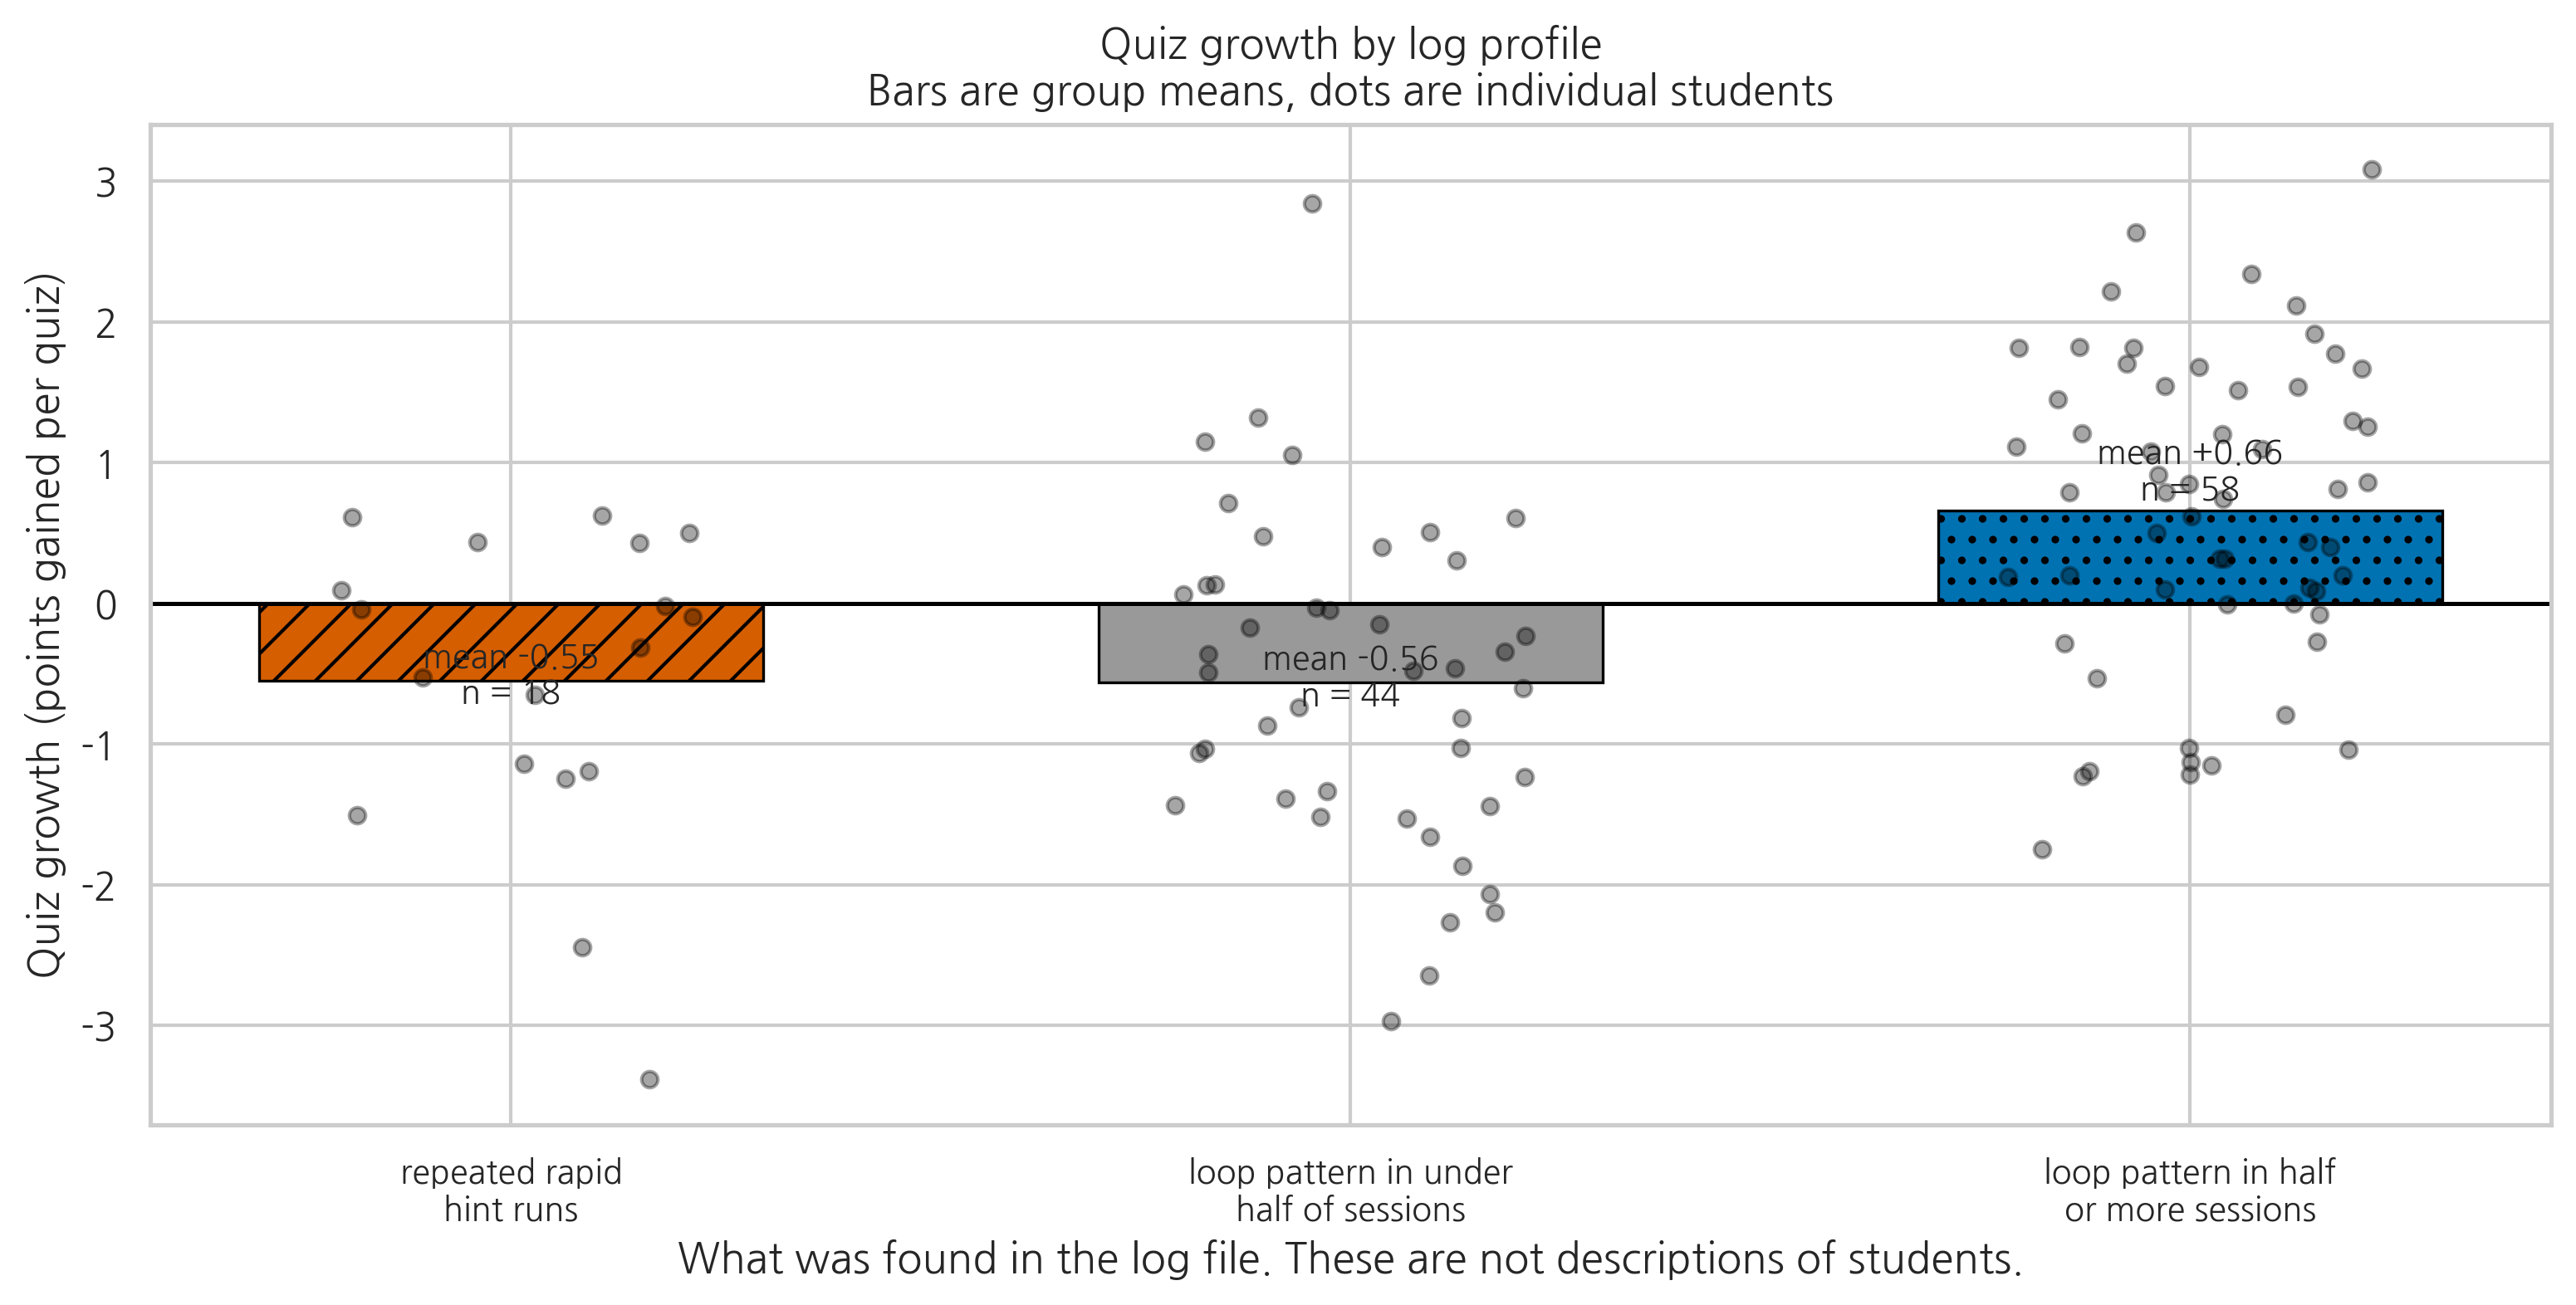

In [18]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
colours = {G_RAPID: "#D55E00", G_LOW: "#999999", G_HIGH: "#0072B2"}
hatches = {G_RAPID: "//", G_LOW: "", G_HIGH: ".."}
WRAPPED = {G_RAPID: "repeated rapid\nhint runs",
           G_LOW: "loop pattern in under\nhalf of sessions",
           G_HIGH: "loop pattern in half\nor more sessions"}
rng = np.random.default_rng(1010)

for i, name in enumerate(GROUP_ORDER):
    values = srl.loc[srl["profile"] == name, "quiz_slope"]
    ax.bar(i, values.mean(), width=0.6, color=colours[name], hatch=hatches[name],
           edgecolor="black", linewidth=0.8, zorder=2)
    ax.scatter(i + rng.uniform(-0.22, 0.22, len(values)), values,
               s=22, color="black", alpha=0.35, zorder=3)
    ax.text(i, values.mean() + (0.08 if values.mean() >= 0 else -0.16),
            f"mean {values.mean():+.2f}\nn = {len(values)}", ha="center", fontsize=9.5, zorder=4)

ax.axhline(0, color="black", linewidth=1.2)
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([WRAPPED[g] for g in GROUP_ORDER], fontsize=9.5)
ax.set_ylabel("Quiz growth (points gained per quiz)")
ax.set_xlabel("What was found in the log file. These are not descriptions of students.")
ax.set_title("Quiz growth by log profile\nBars are group means, dots are individual students")
plt.tight_layout()
plt.show()

**Interpretation prompt, and this one has teeth.**

The high-loop group sits clearly above zero and the other two sit below it. But look again: **the rapid-run group and the low-loop group have almost exactly the same mean growth**, -0.55 against -0.56, and the effect size between them is **d = +0.01 with an interval from -0.54 to +0.56.** On this evidence the two are indistinguishable.

So the headline that a vendor would print, "rapid hint requesting is associated with worse learning", is an artifact of the comparison group. It is true only when you compare the flagged group against a pool that *includes* the high-loop students, and then the difference you are seeing belongs to the loops, not to the hints.

1. Rewrite that headline so that it survives this chart. What did you have to give up, and is what remains worth telling anyone?
2. The dots inside each bar overlap almost completely. If someone handed you this chart together with a list of the 18 flagged students, what would you be entitled to do on Monday morning? Name one thing you would refuse to do, and say who would be harmed if you did it.
3. Notice which group the chart cannot say anything useful about at all: the 44 students in the middle. They are defined by an absence, and an absence in a log has more possible causes than a presence does.
4. We never opened `students.csv` today. Do it now, and ask who the 18 flagged students are: how many work long hours, how many are first generation, how many are multilingual? Week 3 showed that bias enters a model through a feature choice rather than through the algorithm. Our features are a stopwatch and a button. Where would it enter here, and would you be able to see it if it had?

## 📊 5. What follows what: the transition heatmap

The detected-loop rate compresses a whole session to one bit: yes or no. Transitions keep more of the sequence, though still far less than the session had.

An **n-gram** is a run of n consecutive items. We use the simplest case, the **bigram**: every neighbouring pair of actions. Count all the pairs, arrange them in a grid with the earlier action as the row and the later action as the column, then divide each row by its total. Cell (row `attempt`, column `check_answer`) then reads: "when this student had just attempted, they checked their answer 72 percent of the time."

This is a first cousin of what Zhang, Borchers, and Barany do with ordered network analysis, and a much blunter instrument. Theirs models connections across a window of surrounding actions and weights them; ours only sees the action immediately next door. Keep that difference in mind when you read the picture.

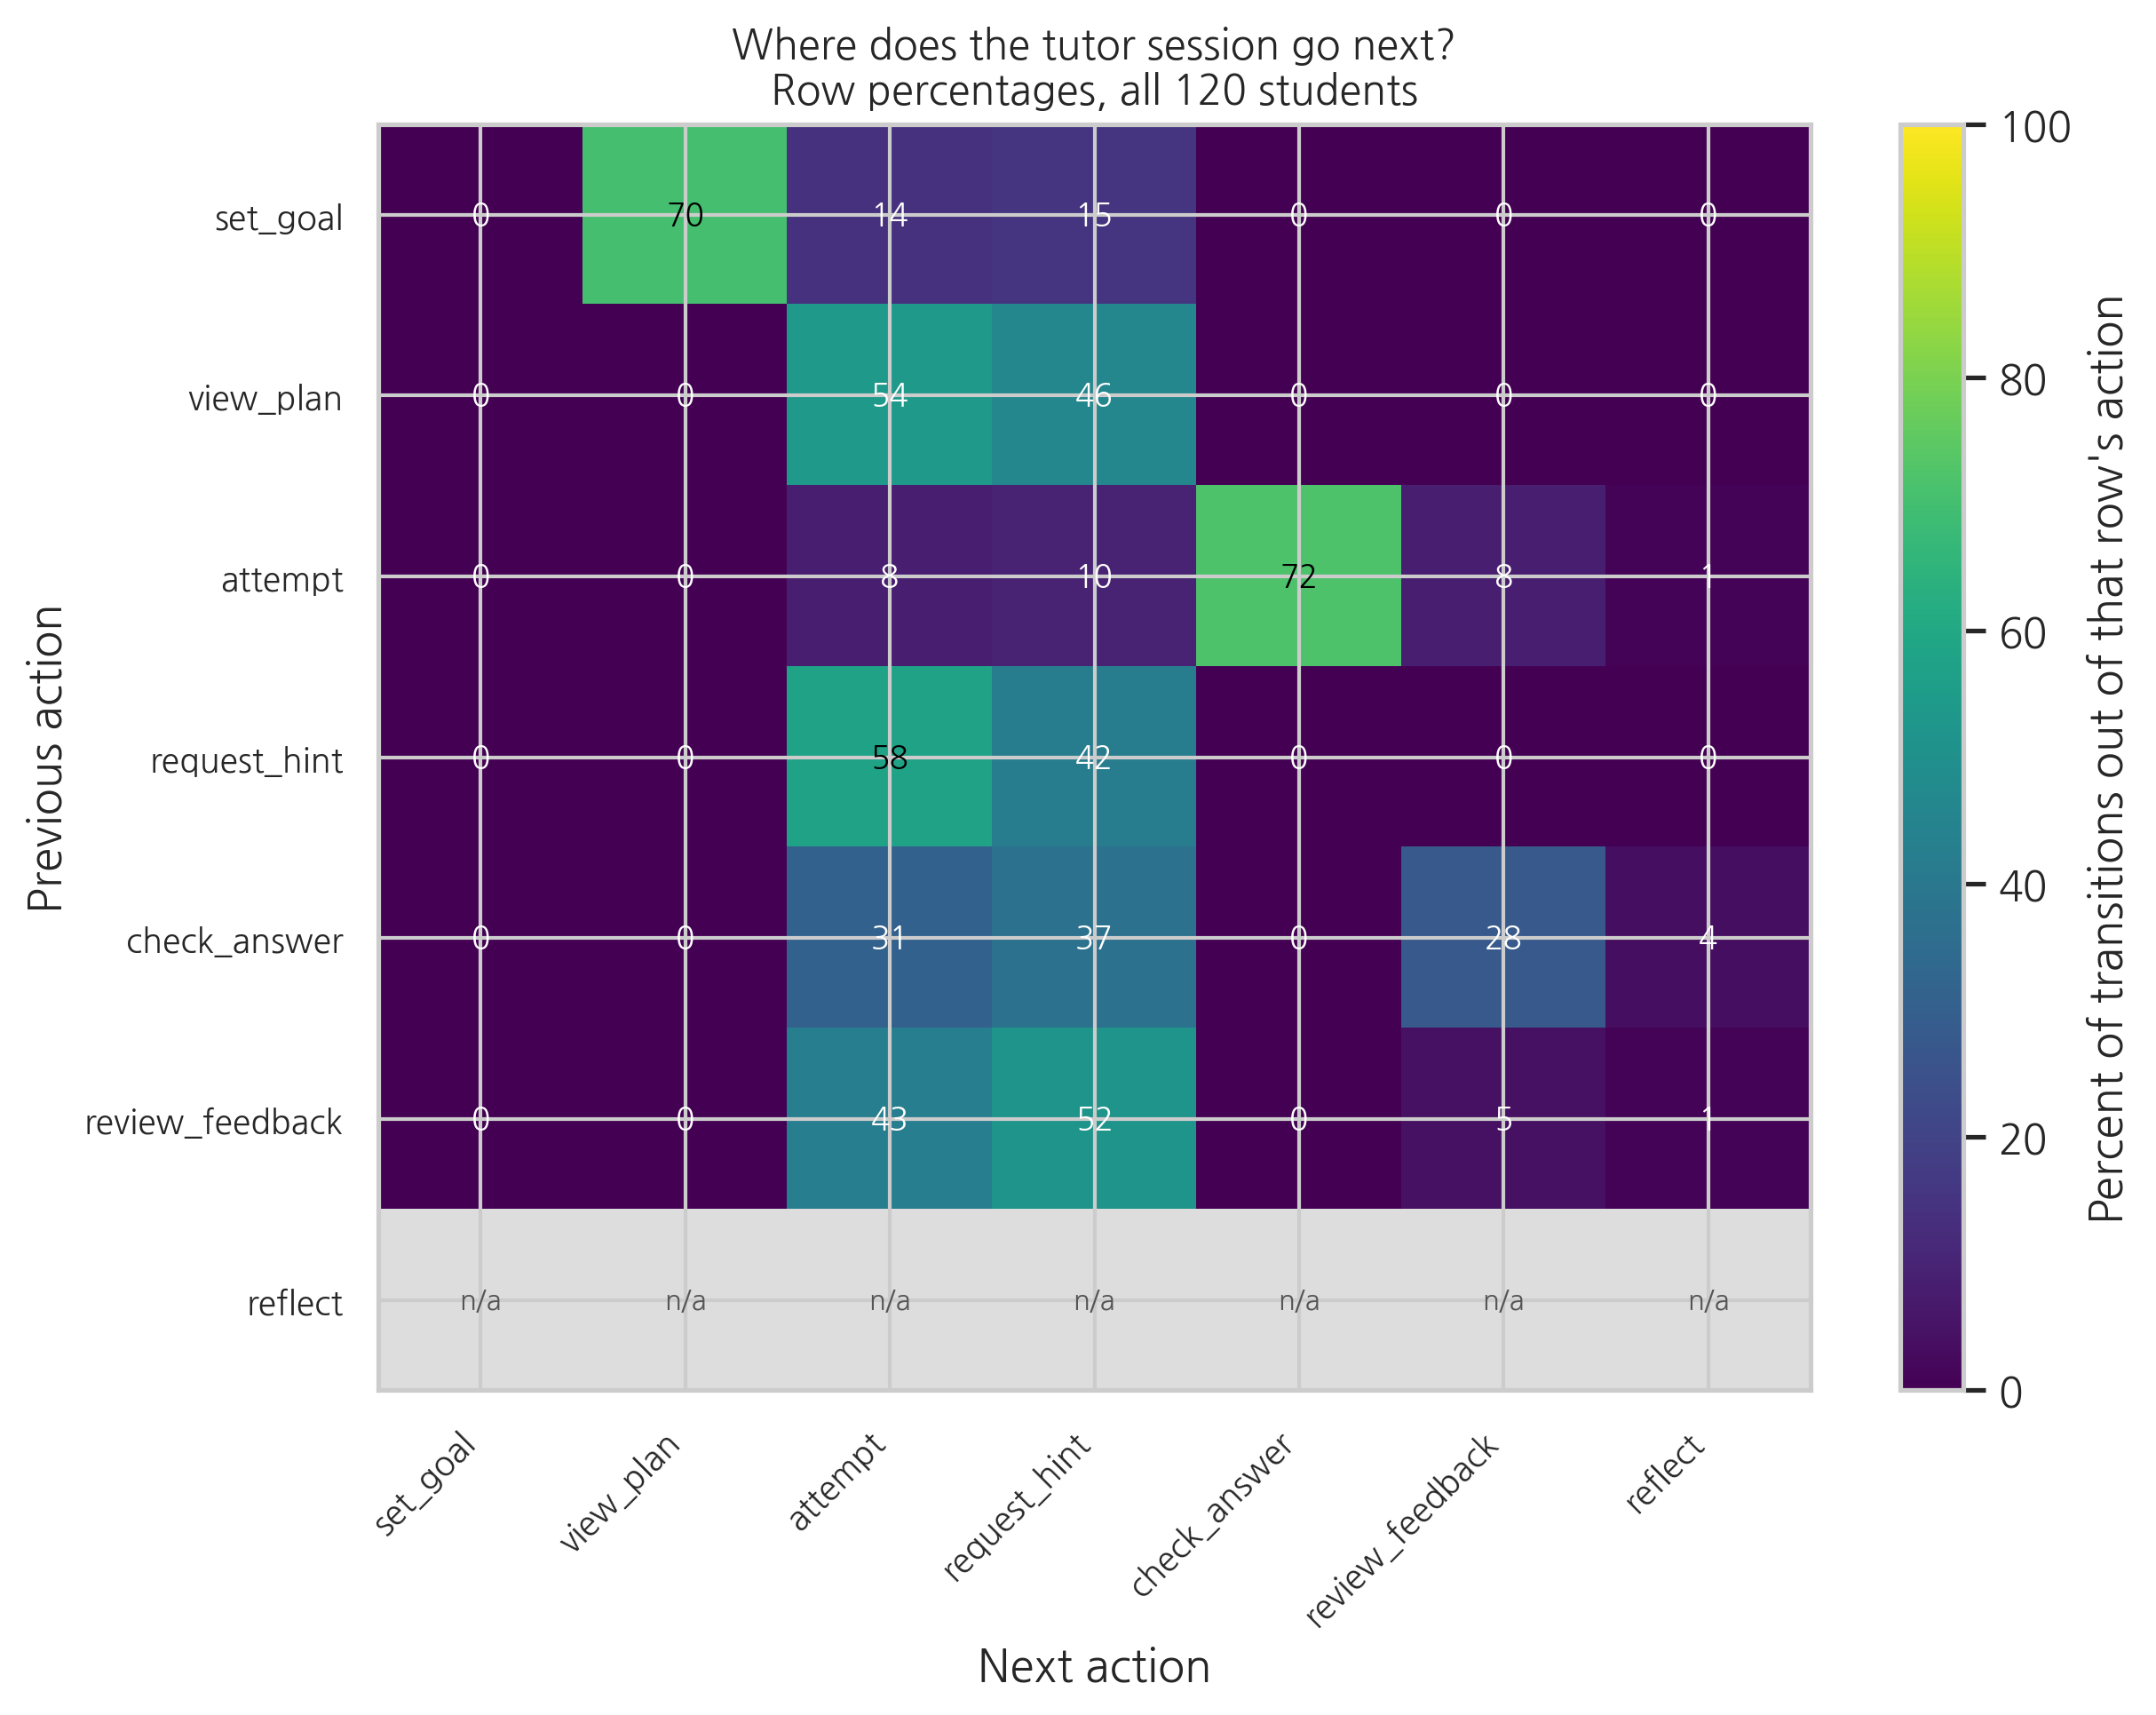

Rows sum to 100 percent. The reflect row is grey because in this tutor
reflect is only ever the last action of a session, so there is no 'next
action' to record. That is a fact about how the log was written rather than
a discovery about students, and it is worth looking for in any real log: an
action that structurally cannot be followed shows up as a striking empty row
and gets read as a striking behavioural finding.


In [19]:
def transition_matrix(frame, actions=ACTIONS):
    """Row-normalized bigram matrix: P(next action | previous action)."""
    pairs = frame.dropna(subset=["previous_action"])
    counts = pd.crosstab(pairs["previous_action"], pairs["action"])
    counts = counts.reindex(index=actions, columns=actions, fill_value=0)
    row_totals = counts.sum(axis=1).replace(0, np.nan)
    return counts.div(row_totals, axis=0)

def draw_heatmap(ax, matrix, title, cmap="viridis", vmin=0, vmax=100, fmt="{:.0f}"):
    data = matrix.values * 100
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("#DDDDDD")
    image = ax.imshow(np.ma.masked_invalid(data), cmap=cmap_obj, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(ACTIONS)))
    ax.set_xticklabels(ACTIONS, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(ACTIONS)))
    ax.set_yticklabels(ACTIONS, fontsize=9)
    ax.set_xlabel("Next action")
    ax.set_ylabel("Previous action")
    ax.set_title(title, fontsize=11)
    span = vmax - vmin
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            if np.isnan(value):
                ax.text(j, i, "n/a", ha="center", va="center", fontsize=7.5, color="#555555")
            else:
                shade = "white" if (value - vmin) < span * 0.55 else "black"
                ax.text(j, i, fmt.format(value), ha="center", va="center",
                        fontsize=8.5, color=shade)
    return image

overall = transition_matrix(traces)

fig, ax = plt.subplots(figsize=(8.4, 6.6))
image = draw_heatmap(ax, overall,
                     "Where does the tutor session go next?\nRow percentages, all 120 students")
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Percent of transitions out of that row's action")
plt.tight_layout()
plt.show()

print("Rows sum to 100 percent. The reflect row is grey because in this tutor")
print("reflect is only ever the last action of a session, so there is no 'next")
print("action' to record. That is a fact about how the log was written rather than")
print("a discovery about students, and it is worth looking for in any real log: an")
print("action that structurally cannot be followed shows up as a striking empty row")
print("and gets read as a striking behavioural finding.")

**Interpretation prompt.** Find the `request_hint` to `request_hint` cell. Across the whole class, a hint request is followed by another hint request 42 percent of the time. Now find `attempt` to `check_answer` at 72 percent.

1. Which single cell in this grid would you put on a teacher's dashboard, and what would the teacher do with it?
2. A class-level heatmap averages over 120 people. What kind of student could be completely invisible in this picture? Section 5.1 answers that; write your guess first.

### 5.1 The same grid, split by log profile

Now compute the identical matrix twice: once from the actions of students whose loop detector fired in half or more of their sessions, once from the actions of students whose logs carry repeated rapid hint runs. The third panel subtracts one from the other, so orange means the first group's logs do it more and purple means the second group's do.

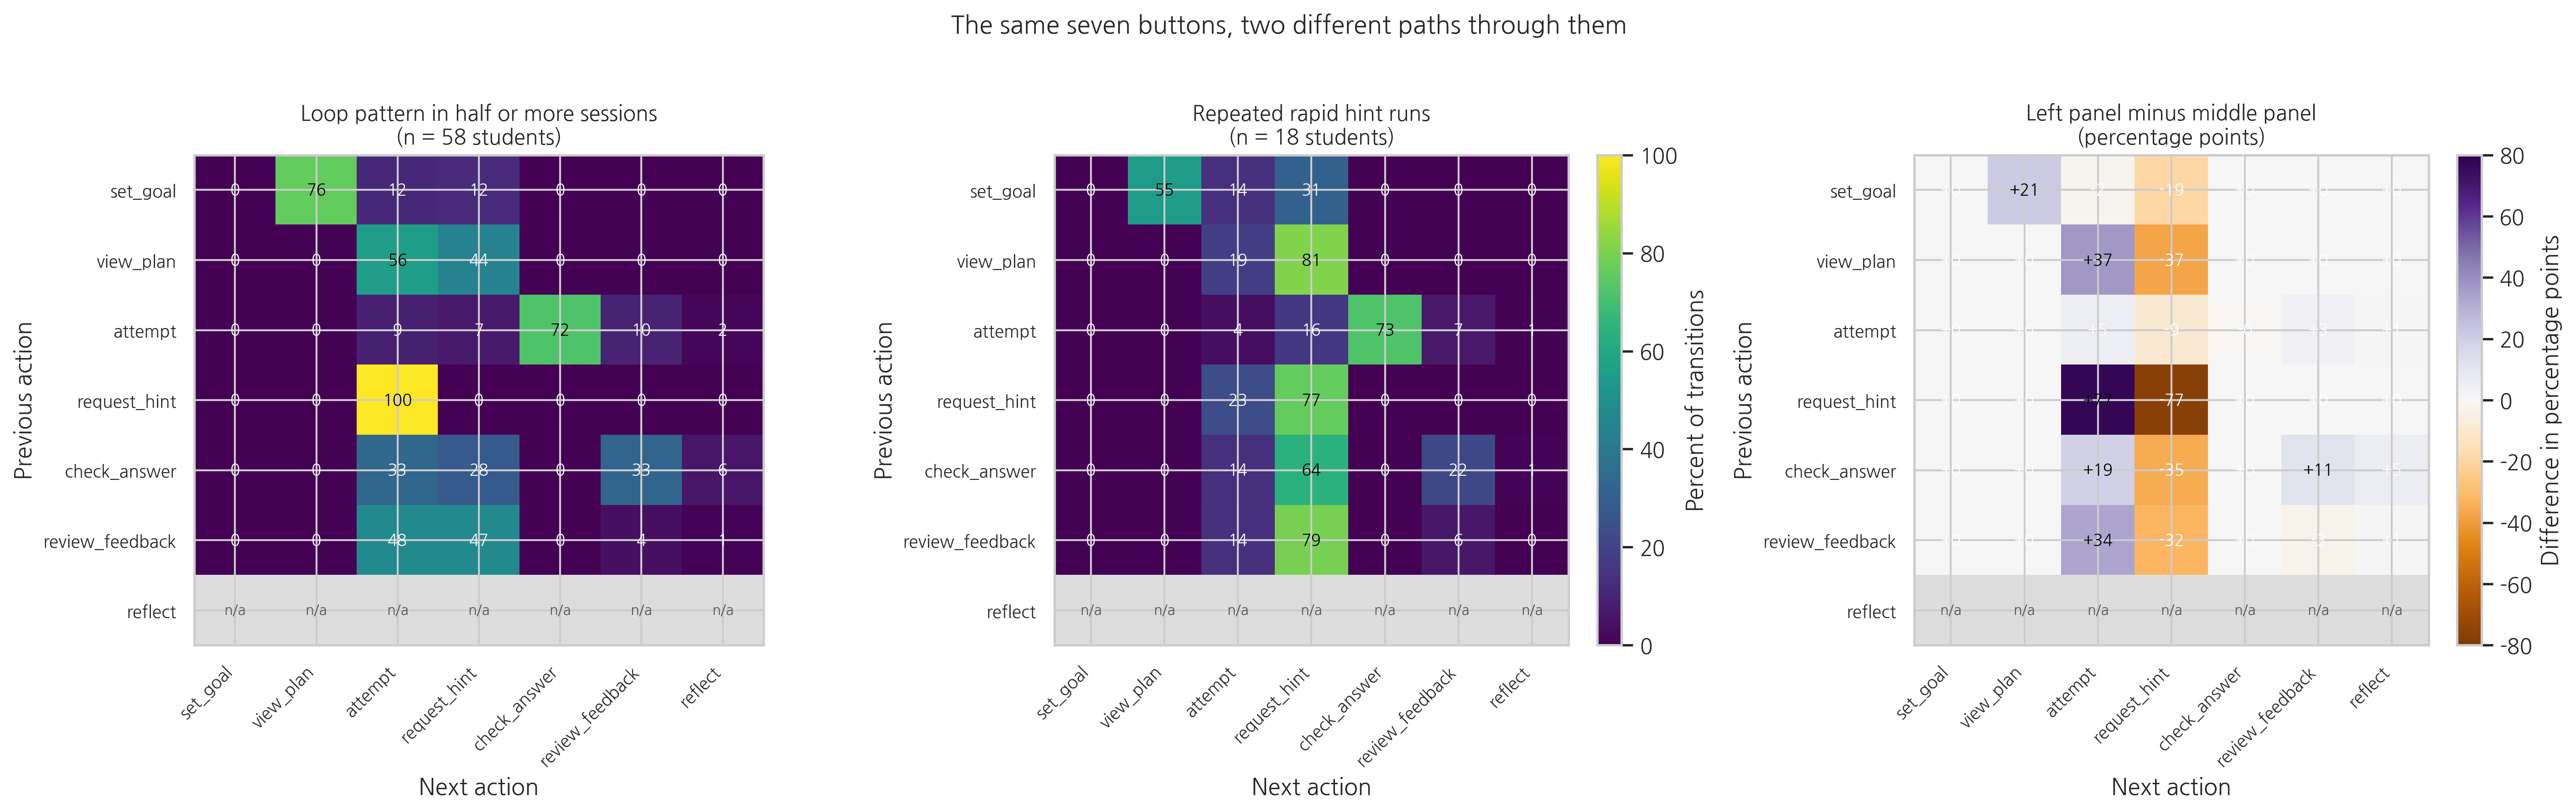

Selected cells, percent of transitions out of the row action
                                 loop pattern >= half  repeated rapid runs             built from hint timing?
request_hint -> request_hint                      0.0                 76.5  yes, the groups were built from it
request_hint -> attempt                         100.0                 23.5                    yes, same reason
check_answer -> review_feedback                  32.6                 21.7                                  no
check_answer -> reflect                           6.0                  0.8                                  no
set_goal -> view_plan                            76.2                 55.2                                  no


In [20]:
loop_half_ids  = srl.index[srl["profile"] == G_HIGH]
rapid_hint_ids = srl.index[srl["profile"] == G_RAPID]

loop_half_matrix  = transition_matrix(traces[traces["student_id"].isin(loop_half_ids)])
rapid_hint_matrix = transition_matrix(traces[traces["student_id"].isin(rapid_hint_ids)])
difference = loop_half_matrix - rapid_hint_matrix

fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))
img1 = draw_heatmap(axes[0], loop_half_matrix,
                    f"Loop pattern in half or more sessions\n(n = {len(loop_half_ids)} students)")
img2 = draw_heatmap(axes[1], rapid_hint_matrix,
                    f"Repeated rapid hint runs\n(n = {len(rapid_hint_ids)} students)")
img3 = draw_heatmap(axes[2], difference,
                    "Left panel minus middle panel\n(percentage points)",
                    cmap="PuOr", vmin=-80, vmax=80, fmt="{:+.0f}")

fig.colorbar(img2, ax=axes[1], fraction=0.046).set_label("Percent of transitions")
fig.colorbar(img3, ax=axes[2], fraction=0.046).set_label("Difference in percentage points")
fig.suptitle("The same seven buttons, two different paths through them",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Selected cells, percent of transitions out of the row action")
cells_of = [("request_hint", "request_hint"), ("request_hint", "attempt"),
            ("check_answer", "review_feedback"), ("check_answer", "reflect"),
            ("set_goal", "view_plan")]
compare = pd.DataFrame({
    "loop pattern >= half": [loop_half_matrix.loc[a, b] * 100 for a, b in cells_of],
    "repeated rapid runs":  [rapid_hint_matrix.loc[a, b] * 100 for a, b in cells_of],
}, index=[f"{a} -> {b}" for a, b in cells_of]).round(1)
compare["built from hint timing?"] = ["yes, the groups were built from it", "yes, same reason",
                                      "no", "no", "no"]
print(compare.to_string())

**Interpretation prompt.** The `request_hint` to `request_hint` cell is 0 percent in the left panel and 77 percent in the middle one. That is about as stark as behavioural data gets, and the first thing to say about it is that **it is circular**: the two groups were built out of hint timing, so of course their hint transitions differ. The last column of the table marks which comparisons are contaminated that way, and the rows marked "no" are the only ones carrying information the grouping did not put there.

1. Take the non-circular contrasts. What do they suggest, and how large are they next to the circular ones? Notice they are far smaller, which is what an uncontaminated contrast usually looks like.
2. The heatmap treats a two-second transition and a four-minute transition as the same event. Design a fix. What would you have to add to the matrix, and what would you lose in readability?
3. The middle panel rests on 18 students and the left on 58. Row percentages from a small group bounce. Which cells in the middle panel would you refuse to quote to one decimal place?
4. Ordered network analysis, in the Zhang, Borchers, and Barany reading, connects actions across a window rather than only to the immediate neighbour. Looking at these three panels, what would a wider window let you see that you cannot see here, and what new analyst decision would it introduce?

### ✏️ Your turn 4 (stretch)

Instead of splitting by our derived profiles, split by an outcome and see whether the transitions still separate. The default splits students at the median quiz growth. Change `SPLIT_COLUMN` to `"detected_loop_rate"` to split on regulation instead, or edit the grouping rule entirely.

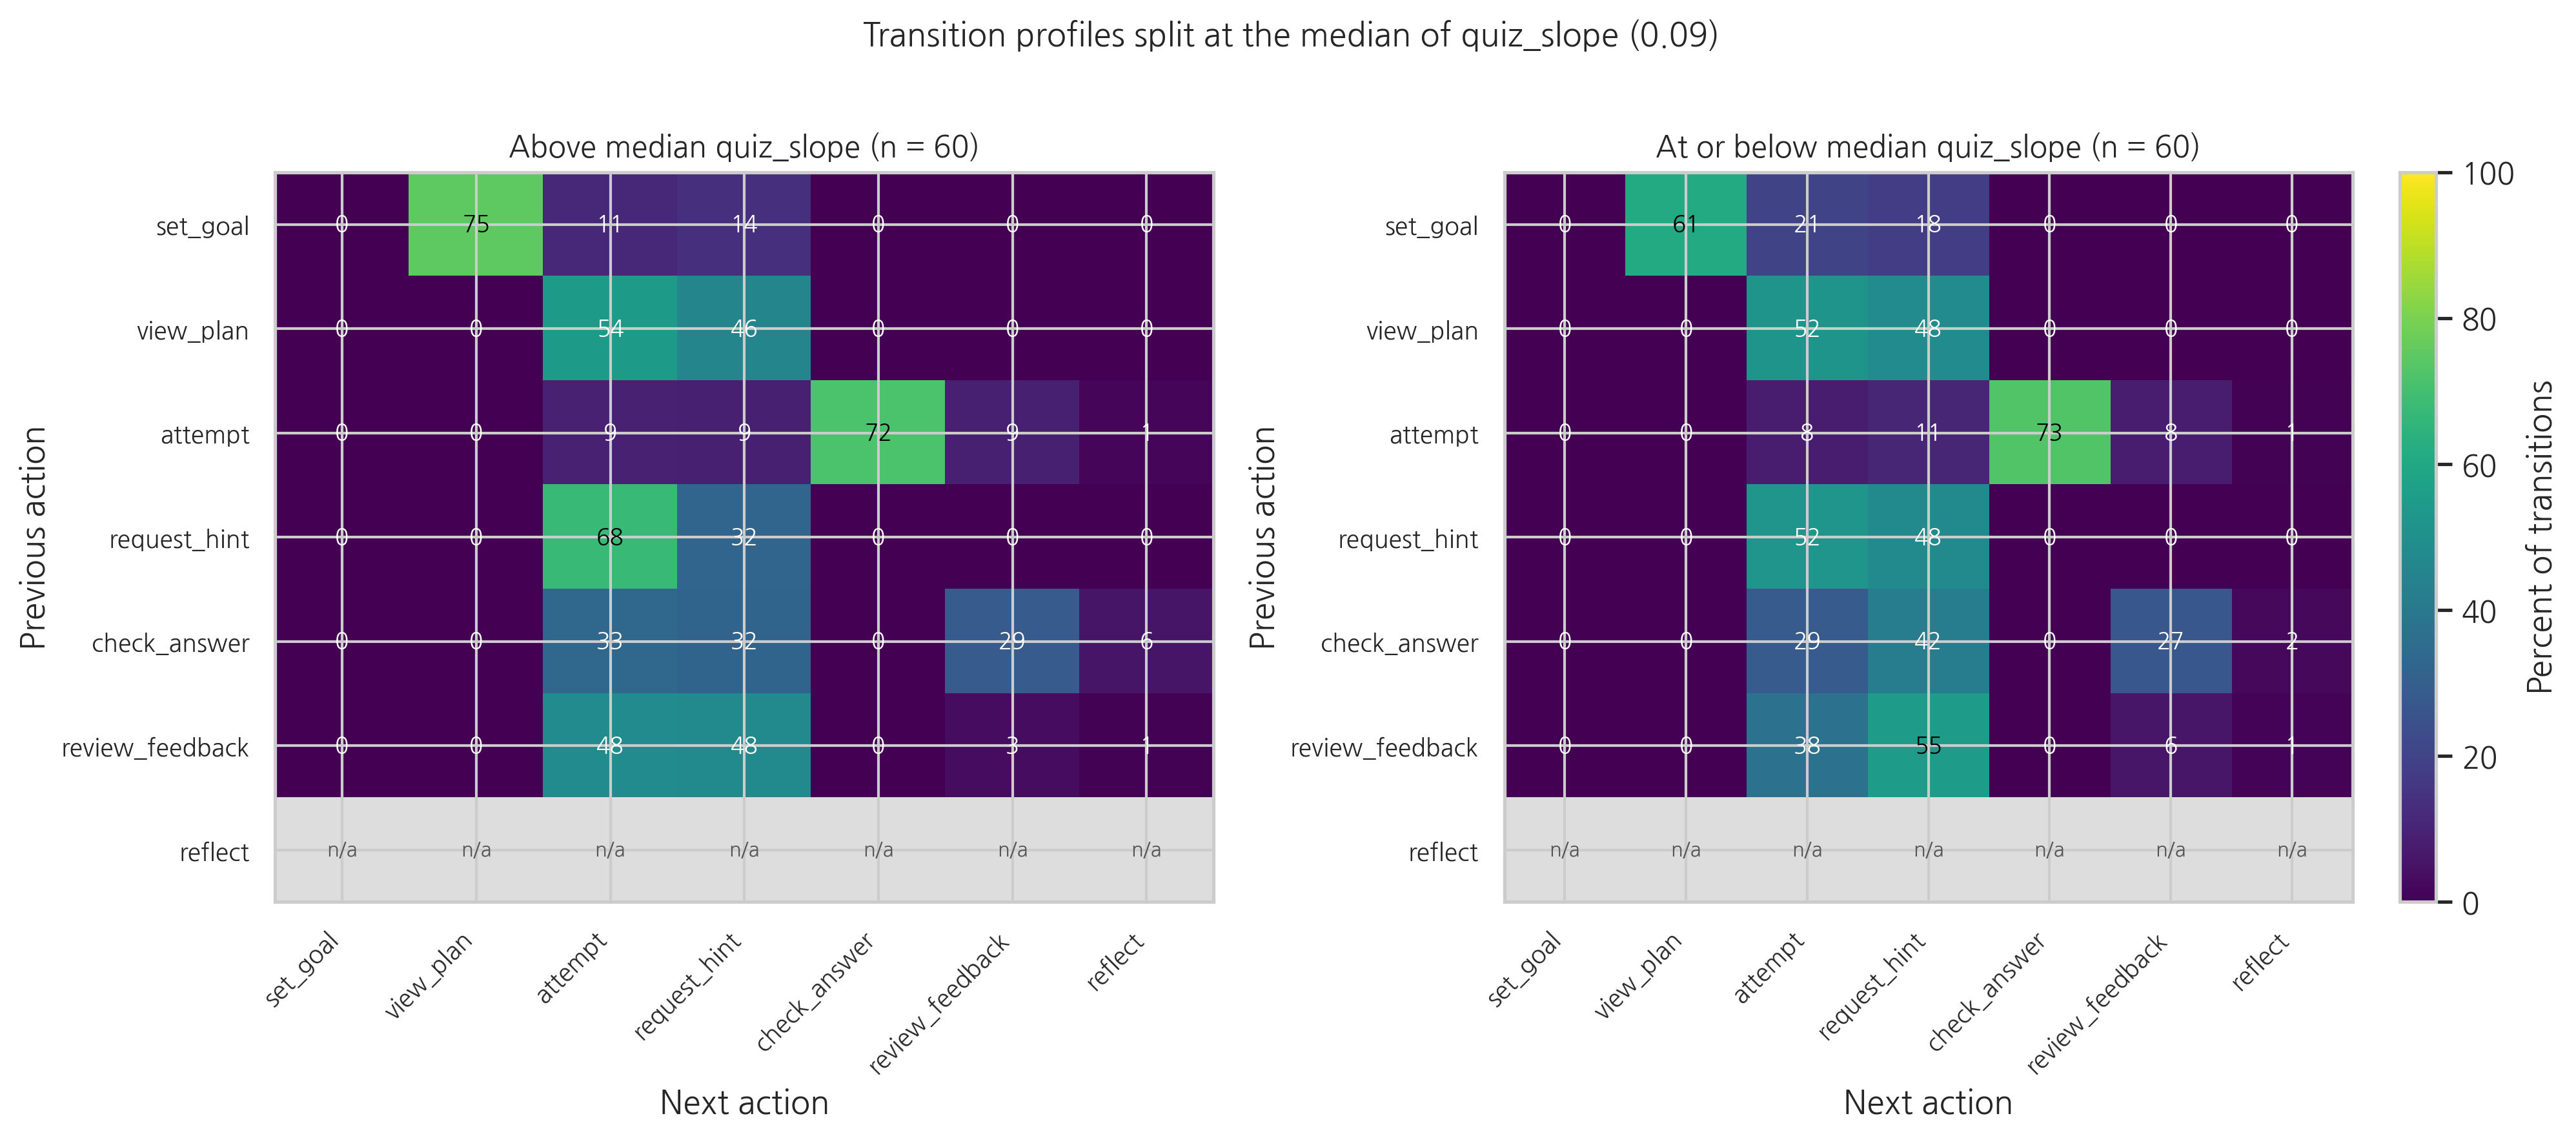

Largest differences between the two halves, in percentage points
      request_hint -> request_hint      -15.4
      request_hint -> attempt           +15.4
          set_goal -> view_plan         +14.0
   review_feedback -> attempt           +10.6
      check_answer -> request_hint       -9.9


In [21]:
# ✏️ TODO: try "detected_loop_rate" instead of "quiz_slope".
SPLIT_COLUMN = "quiz_slope"

cutoff = srl[SPLIT_COLUMN].median()
high_ids = srl.index[srl[SPLIT_COLUMN] > cutoff]
low_ids = srl.index[srl[SPLIT_COLUMN] <= cutoff]

high_matrix = transition_matrix(traces[traces["student_id"].isin(high_ids)])
low_matrix = transition_matrix(traces[traces["student_id"].isin(low_ids)])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))
draw_heatmap(axes[0], high_matrix, f"Above median {SPLIT_COLUMN} (n = {len(high_ids)})")
img = draw_heatmap(axes[1], low_matrix, f"At or below median {SPLIT_COLUMN} (n = {len(low_ids)})")
fig.colorbar(img, ax=axes[1], fraction=0.046).set_label("Percent of transitions")
fig.suptitle(f"Transition profiles split at the median of {SPLIT_COLUMN} "
             f"({cutoff:.2f})", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

biggest = (high_matrix - low_matrix).abs().stack().sort_values(ascending=False).head(5)
print("Largest differences between the two halves, in percentage points")
for (previous, nxt), value in ((high_matrix - low_matrix).stack()
                               .reindex(biggest.index).items()):
    print(f"  {previous:>16} -> {nxt:<16} {value * 100:+6.1f}")

## 💬 Reflection

Bring written answers to at least two of these. They are the spine of tonight's discussion.

**On Winne (2022), "Learning analytics for self-regulated learning."**
Winne argues that self-regulated learning is not directly observable and that traces are the footprints it leaves. Today you turned footprints into a detected-loop rate. Name the single largest thing that measure gets wrong about a real student's regulation, and say whether more trace data would fix it or whether the problem is of a different kind. Then the version with teeth: about a student whose detector never fired, what have you actually learned?

**On Zhang, Borchers, and Barany (2024), "Studying the interplay of self-regulated learning cycles and scaffolding through ordered network analysis across three tutoring systems."**
Their analysis looks at how regulation cycles interact with the scaffolding the system offers, across three different tutors. Our tutor offers hints, feedback, and a plan view. Pick one of those three supports and argue, using something you saw in a chart today, that the support is shaping the regulation we measured rather than merely revealing it.

**On Viberg, Khalil, and Baars (2020), "Self-regulated learning and learning analytics in online learning environments."**
Their review asks how much learning analytics work on SRL actually measures SRL and how much of it measures activity wearing an SRL vocabulary. Where does today's notebook sit on that line? Be specific: which of our four measures would you defend as SRL, and which is activity with a nicer name?

**Across all three, and the course.**
In Week 3 we found that bias entered a model of non-completion through a feature choice, not through the algorithm. Today we made at least seven choices: which actions count as a goal, which count as closing a loop, ten seconds, three in a row, three runs across a term rather than a rate per session, where to cut the detected-loop rate at one half, and what to call the three groups. Pick the one you think is most consequential and least defensible, and say what evidence would settle it.

Then an eighth, which is not a modelling choice at all. Section 2 showed that the ordering requirement in our loop definition picked out exactly the same sessions as a two-item checklist. Does the phrase "regulation loop" survive that? If not, what should the measure have been called from the start, and would anyone have read a paper about it?

### A question for our guest

Conrad Borchers joins us this week and is a coauthor of the Zhang, Borchers, and Barany reading. [Bio: confirm with speaker]

Come with a real question. The strongest ones come from something you actually just did. For example, our rapid-hint-run flag hangs on a ten second threshold that we picked, and ordered network analysis hangs on a window size that its analyst picks. A question worth asking:

> "When you build ordered networks across three different tutoring systems, how do you choose the window within which two actions count as connected, and how much do your substantive conclusions move when that choice changes? Is there a defensible way to report that sensitivity, or does the field just have to trust the analyst?"

Write your own version, or write a better one. Bring it on paper.

## ✅ Before you leave today

**There is nothing to upload to Canvas this week.** Week 7 has no mini project. This lab is a launch: we start it together in class and you finish reading and arguing with it on your own time. The next Canvas deliverable is Mini Project 4, due Week 8.

Checklist for tonight:

- [ ] The notebook ran top to bottom with no errors (**Runtime > Restart and run all**).
- [ ] You can state the **loop detector's** definition from memory, and say in one sentence what it detects (an ordered sequence in a log) and what it does not (regulation). Week 11 puts this lab back on the table and asks who should have had a say in the labels it produced.
- [ ] You changed at least one threshold in a **✏️ Your turn** cell and noticed what moved.
- [ ] You have written answers to at least two 💬 Reflection prompts.
- [ ] You have one question written down for Conrad Borchers.

**AI use, per the course policy.** AI assistance is permitted in designated activities and must be documented. There is no submission this week, so there is nothing to log today. The moment any of this code, or any AI conversation about it, makes its way into a mini project or your course research project, the full policy applies: you upload your AI interaction log and a short reflection alongside the work. Undisclosed use is an Honor Code violation. The habit that makes this painless is to keep the log as you go rather than reconstructing it afterward.

## Appendix: solutions to the ✏️ Your turn cells

These are worked versions, not the only right answers. Run them after you have tried your own.

### Solution 1: comparing several students' profiles at once

Rather than one student at a time, put a few side by side and let the differences do the talking.

Percent of each student's actions, by action type
student_id       S017  S047  S072  S003  class median
action                                               
set_goal          0.0   0.0   1.5   0.0           1.5
view_plan         0.0   0.0   1.5   0.0           0.9
attempt          33.7  16.6  19.9  45.9          37.5
request_hint     27.2  64.1  62.0  16.2          19.1
check_answer     24.4  11.8  12.9  32.4          27.1
review_feedback  14.7   7.3   1.8   5.4           9.0
reflect           0.0   0.1   0.4   0.0           1.3


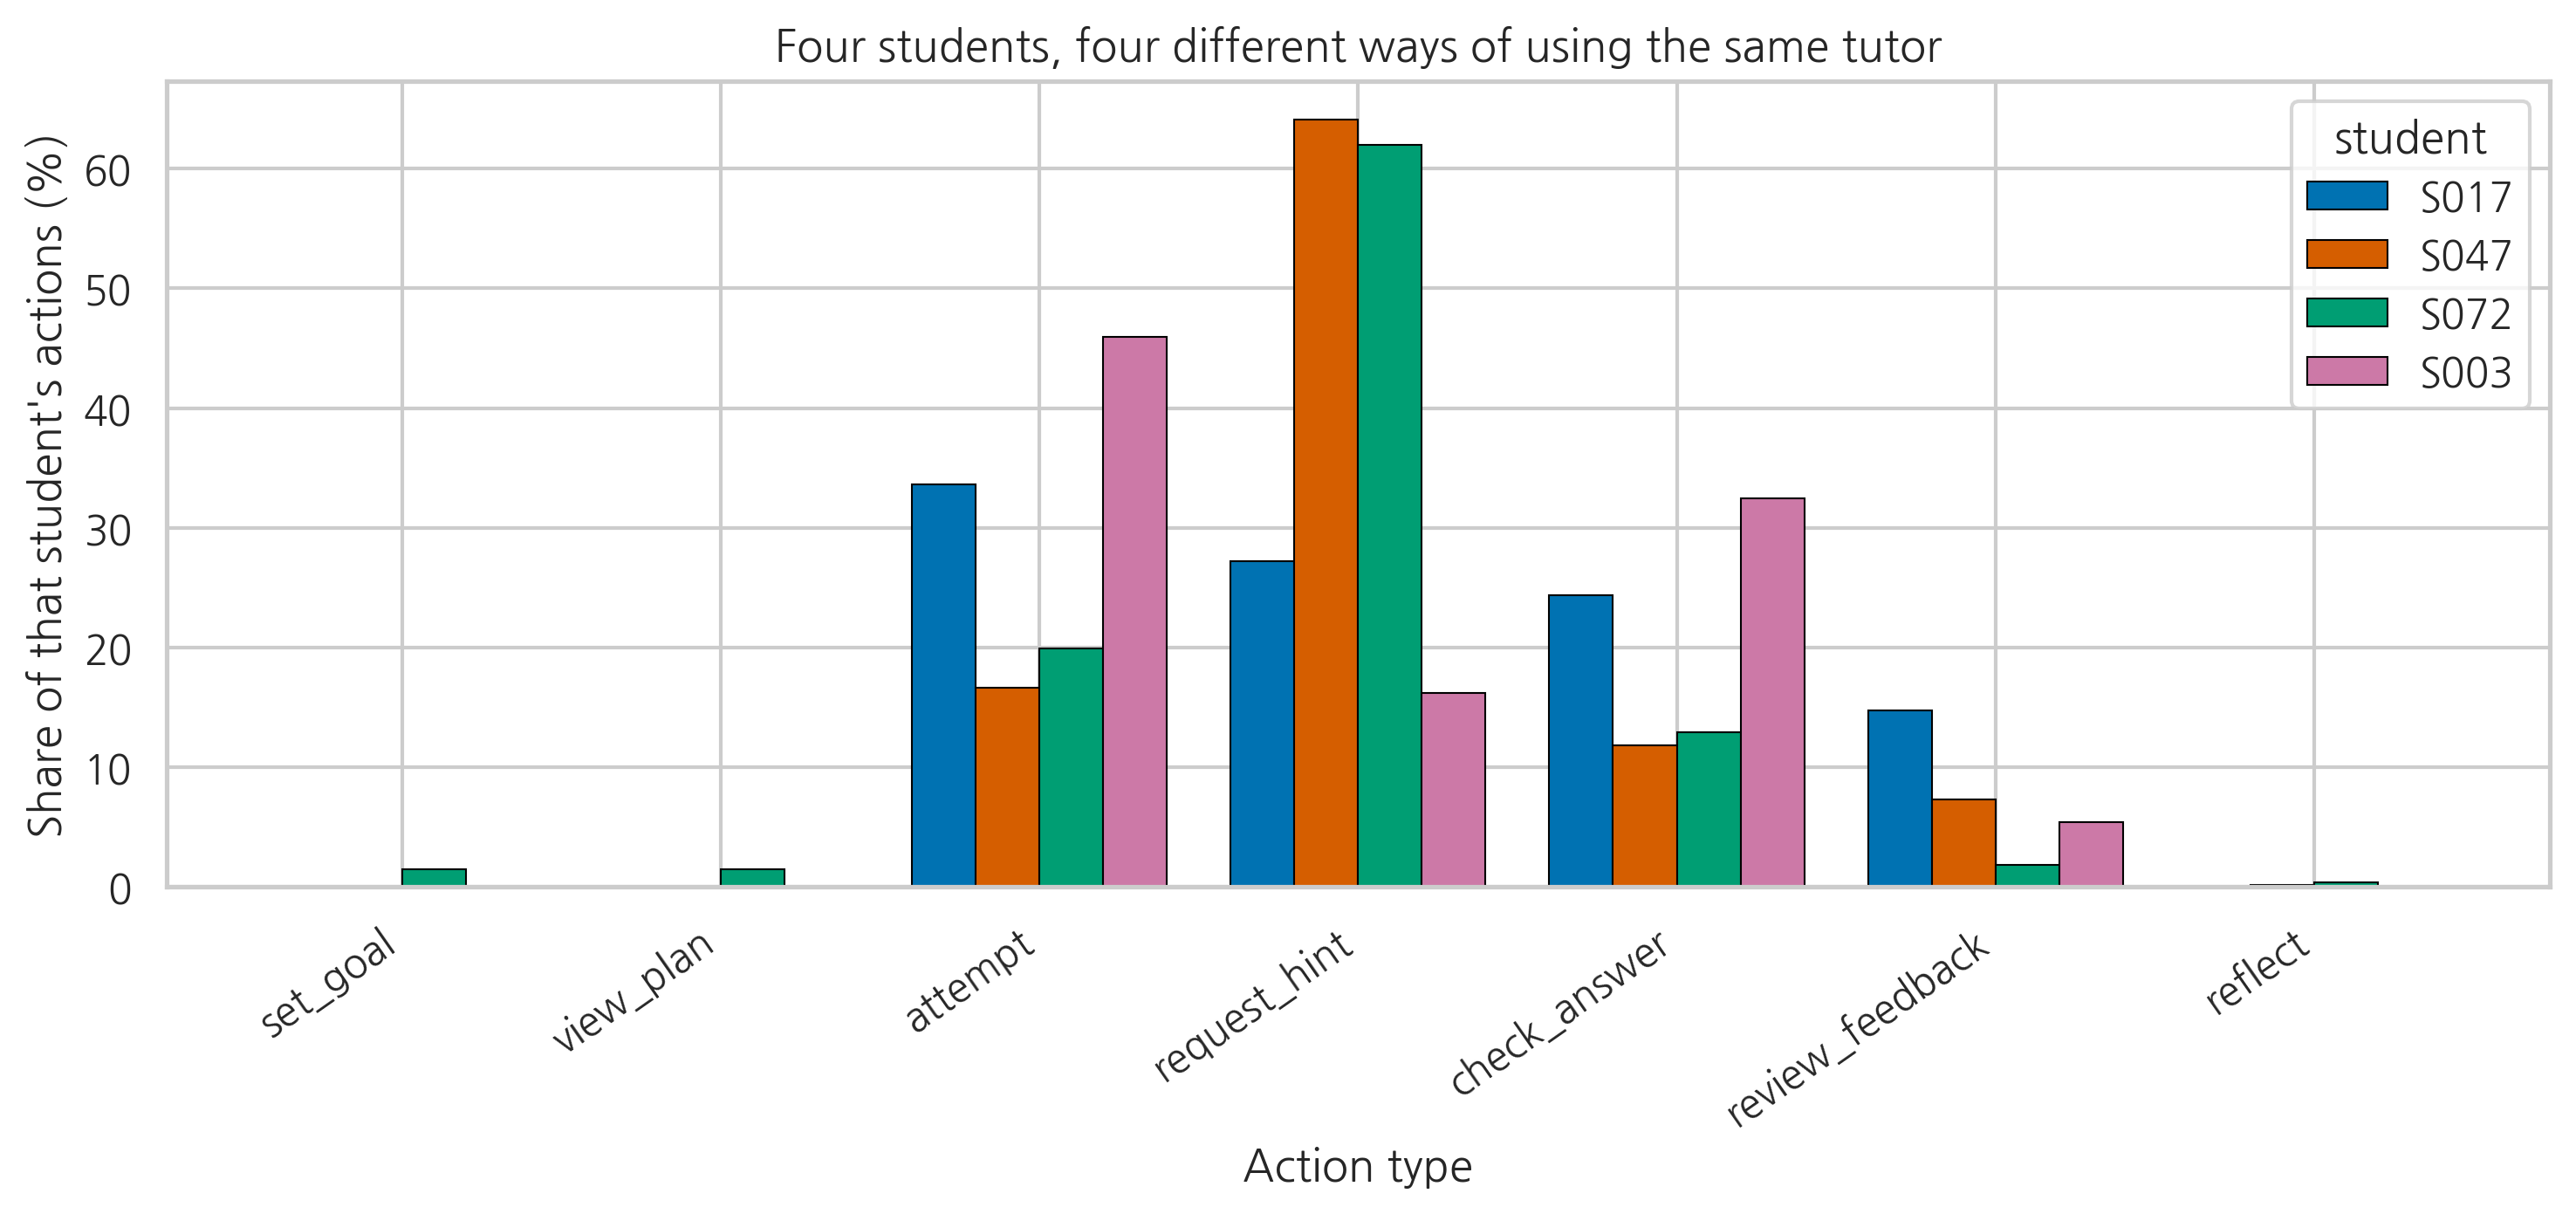

In [22]:
SOME_STUDENTS = ["S017", "S047", "S072", "S003"]

side_by_side = (profile.loc[SOME_STUDENTS] * 100).round(1).T
side_by_side["class median"] = (profile.median() * 100).round(1)
print("Percent of each student's actions, by action type")
print(side_by_side.to_string())

fig, ax = plt.subplots(figsize=(10, 4.8))
width = 0.2
positions = np.arange(len(ACTIONS))
palette = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
for k, student_id in enumerate(SOME_STUDENTS):
    ax.bar(positions + (k - 1.5) * width, profile.loc[student_id, ACTIONS] * 100,
           width=width, label=student_id, color=palette[k], edgecolor="black", linewidth=0.5)
ax.set_xticks(positions)
ax.set_xticklabels(ACTIONS, rotation=35, ha="right")
ax.set_ylabel("Share of that student's actions (%)")
ax.set_xlabel("Action type")
ax.set_title("Four students, four different ways of using the same tutor")
ax.legend(title="student")
plt.tight_layout()
plt.show()

### Solution 2: how the loop definition changes the finding

Sweep several definitions of "closing the loop" and watch both the prevalence and the correlation move.

In [23]:
definitions = {
    "reflect only": ("reflect",),
    "review_feedback only": ("review_feedback",),
    "either one (notebook default)": ("review_feedback", "reflect"),
    "either one, or a plan view": ("review_feedback", "reflect", "view_plan"),
}

rows = []
for name, closers in definitions.items():
    flags = session_actions["action_sequence"].apply(
        lambda seq, c=closers: contains_loop_pattern(seq, closers=c))
    rate = flags.groupby(session_actions["student_id"]).mean()
    rows.append({"definition": name,
                 "sessions with a loop (%)": round(flags.mean() * 100, 1),
                 "correlation with quiz growth": round(rate.corr(quiz_slope), 2)})
print(pd.DataFrame(rows).to_string(index=False))
print()
print("The prevalence swings by tens of percentage points. The correlation moves much less,")
print("which is itself worth a sentence in a paper: the ordering of students is more stable")
print("than the headline number, so a claim about who regulates survives better than a claim")
print("about how much regulation happened.")

                   definition  sessions with a loop (%)  correlation with quiz growth
                 reflect only                      30.6                          0.52
         review_feedback only                      43.8                          0.53
either one (notebook default)                      48.6                          0.58
   either one, or a plan view                      48.6                          0.58

The prevalence swings by tens of percentage points. The correlation moves much less,
which is itself worth a sentence in a paper: the ordering of students is more stable
than the headline number, so a claim about who regulates survives better than a claim
about how much regulation happened.


### Solution 3: a sensitivity analysis of the rapid-hint-run thresholds

One number at a time is fine for exploring. For an argument you want the whole surface, because a reader is entitled to know whether your result lives on a plateau or on a cliff edge.

In [24]:
gap_options = [3, 5, 10, 20, 45]
length_options = [2, 3, 4, 5]

grid = pd.DataFrame(index=[f"{g} s" for g in gap_options],
                    columns=[f"{n} in a row" for n in length_options], dtype=float)
for gap in gap_options:
    rapid = ((traces["action"] == "request_hint") &
             (traces["previous_action"] == "request_hint") &
             (traces["gap_s"] < gap))
    for length in length_options:
        runs = rapid.groupby(traces["student_id"]).apply(
            lambda flags, L=length: count_runs(flags, min_length=L))
        grid.loc[f"{gap} s", f"{length} in a row"] = int((runs >= MIN_RUNS_TO_FLAG).sum())

print("Logs flagged for repeated rapid hint runs, under every combination of thresholds")
print("(requiring at least", MIN_RUNS_TO_FLAG, "runs across the term)")
print(grid.astype(int).to_string())
print()
flat = grid.values.ravel()
print(f"Range across the grid: {int(flat.min())} to {int(flat.max())} students flagged.")
print()
print("Read the corner, not the middle. Across most of this grid the count sits at 18,")
print("because the planted behaviour is extreme: runs of hints two to six seconds apart,")
print("dozens of times. But move to a 3 second gap and require 4 in a row, which is a")
print("perfectly defensible rule that someone might argue is the only honest one, and the")
print("flag collapses from 18 students to 1. At 3 seconds and 5 in a row it reaches zero.")
print()
print("So the correct summary is NOT 'the flag is stable'. It is: 'the flag is stable")
print("across a broad plateau and falls off a cliff at the strictest corner, and which")
print("side of that cliff you land on is decided by an analyst, not by a student.'")
print("Report a table like this one whenever a threshold is doing load-bearing work.")

Logs flagged for repeated rapid hint runs, under every combination of thresholds
(requiring at least 3 runs across the term)
      2 in a row  3 in a row  4 in a row  5 in a row
3 s           18          16           1           0
5 s           18          18          18          16
10 s          18          18          18          18
20 s          18          18          18          18
45 s          18          18          18          18

Range across the grid: 0 to 18 students flagged.

Read the corner, not the middle. Across most of this grid the count sits at 18,
because the planted behaviour is extreme: runs of hints two to six seconds apart,
dozens of times. But move to a 3 second gap and require 4 in a row, which is a
perfectly defensible rule that someone might argue is the only honest one, and the
flag collapses from 18 students to 1. At 3 seconds and 5 in a row it reaches zero.

So the correct summary is NOT 'the flag is stable'. It is: 'the flag is stable
across a broad plat

### Solution 4: which transitions separate the outcome halves

A quick ranked list is often more useful than staring at a 7 by 7 grid.

In [25]:
above = srl.index[srl["quiz_slope"] > srl["quiz_slope"].median()]
below = srl.index[srl["quiz_slope"] <= srl["quiz_slope"].median()]
diff = (transition_matrix(traces[traces["student_id"].isin(above)]) -
        transition_matrix(traces[traces["student_id"].isin(below)])) * 100

ranked = diff.stack().dropna().sort_values(key=abs, ascending=False).head(8)
print("Transitions that most separate higher growth from lower growth students")
print("(positive means the higher growth half does it more, in percentage points)")
for (previous, nxt), value in ranked.items():
    print(f"  {previous:>16} -> {nxt:<18} {value:+6.1f}")
print()
print("Compare this list with the profile comparison in Section 5.1. A transition appearing")
print("in both is a candidate for a behavioural signal that the grouping did not manufacture.")
print("A transition appearing only in the profile comparison is probably an artifact of how")
print("we drew the groups, since hint timing built them. And remember the ceiling on all of")
print("it: this is a simulated tutor whose generator wrote these associations in by hand.")

Transitions that most separate higher growth from lower growth students
(positive means the higher growth half does it more, in percentage points)
      request_hint -> request_hint        -15.4
      request_hint -> attempt             +15.4
          set_goal -> view_plan           +14.0
   review_feedback -> attempt             +10.6
      check_answer -> request_hint         -9.9
          set_goal -> attempt              -9.7
   review_feedback -> request_hint         -7.4
      check_answer -> attempt              +4.7

Compare this list with the profile comparison in Section 5.1. A transition appearing
in both is a candidate for a behavioural signal that the grouping did not manufacture.
A transition appearing only in the profile comparison is probably an artifact of how
we drew the groups, since hint timing built them. And remember the ceiling on all of
it: this is a simulated tutor whose generator wrote these associations in by hand.


---

*EDIS 8100: Teaching and Learning Analytics. Course design and data universe by Dr. Hakeoung Hannah Lee, University of Virginia School of Education and Human Development. All data in this notebook are synthetic.*